<h3  style = "color: skyblue" >Importing Libraries<h3>

In [199]:
import math
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import KFold, GridSearchCV, RandomizedSearchCV, train_test_split

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


<h3  style = "color: skyblue" >Data Ingestion and Loading<h3>

In [200]:
df = pd.read_excel("../data/premiums.xlsx")
print("Few observations:")
df.head()

Few observations:


,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365


<h3 style = "color:skyblue" >Data Overview</h3>

In [201]:
print("Number of rows and columns:", df.shape)
print("Number of duplicated observations:", df.duplicated().sum())
print("====" * 10)
print("Data Types of each fields:\n")
print(df.dtypes)
print("====" * 10)
print("Number of missing values per columns:")
df.isna().sum()

Number of rows and columns: (50000, 13)
Number of duplicated observations: 0
Data Types of each fields:

Age                       int64
Gender                   object
Region                   object
Marital_status           object
Number Of Dependants      int64
BMI_Category             object
Smoking_Status           object
Employment_Status        object
Income_Level             object
Income_Lakhs              int64
Medical History          object
Insurance_Plan           object
Annual_Premium_Amount     int64
dtype: object
Number of missing values per columns:


Age                       0
Gender                    0
Region                    0
Marital_status            0
Number Of Dependants      0
BMI_Category              0
Smoking_Status           11
Employment_Status         2
Income_Level             13
Income_Lakhs              0
Medical History           0
Insurance_Plan            0
Annual_Premium_Amount     0
dtype: int64

<h3 style = "color:skyblue" >Sanity Cleaning</h3>

In [202]:
#making field names consistent
df.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number Of Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical History', 'Insurance_Plan',
       'Annual_Premium_Amount'],
      dtype='object')

In [203]:
#lower + snakecase
df.columns = df.columns.str.replace(' ', '_').str.lower()
df.columns

Index(['age', 'gender', 'region', 'marital_status', 'number_of_dependants',
       'bmi_category', 'smoking_status', 'employment_status', 'income_level',
       'income_lakhs', 'medical_history', 'insurance_plan',
       'annual_premium_amount'],
      dtype='object')

In [204]:
#since the number of missng value is small we can delete it
df.dropna(inplace=True)
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

<h3 style = "color:skyblue" >Exploratory Data Analysis</h3>

#### 1. Summary Stats

In [205]:
print("Quick Summary Statistics:")
df.describe()

Quick Summary Statistics:


,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49976.000000,49976.000000,49976.000000,49976.000000
mean,34.591764,1.711842,23.021150,15766.810189
std,15.000378,1.498195,24.221794,8419.995271
min,18.000000,-3.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8607.750000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22273.500000
max,356.000000,5.000000,930.000000,43471.000000


Problems -
* certainly an outliers in the `age` field.
* number of dependants cannot be `negative`
* maybe an outlier in income_lakhs

In [206]:
# solve for the number of dependants
df['number_of_dependants'].unique()

array([ 0,  2,  3,  4,  1,  5, -3, -1], dtype=int64)

In [207]:
# there are 72 observations that is less that has negative values
# there may be some error in data entry and maybe it is +ve values
# talked to business and they said to replace with +ve values 
df[df['number_of_dependants'] < 0].shape

(72, 13)

In [208]:
df['number_of_dependants'] = df['number_of_dependants'].abs()
df['number_of_dependants'].unique()

array([0, 2, 3, 4, 1, 5], dtype=int64)

#### 2. Univariate Analysis - numeric 

In [209]:
numeric_columns = df.select_dtypes('number').columns
numeric_columns

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount'], dtype='object')

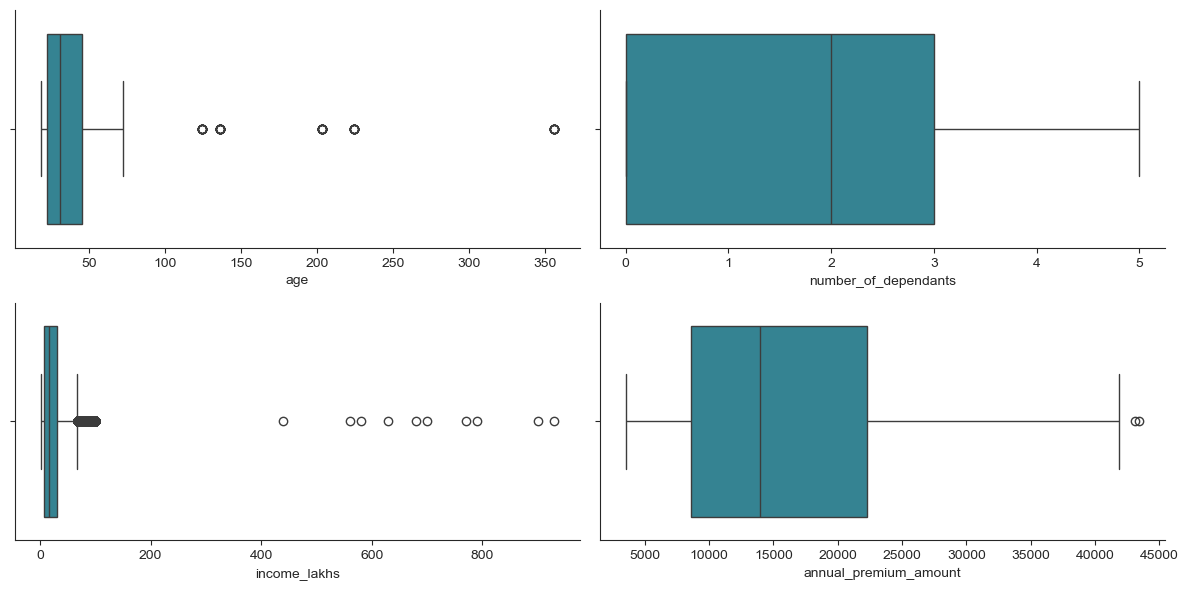

In [210]:
#solve for outliers
#numeric
plt.figure(figsize=(12, 6))

ncols = 2
nrows = math.ceil(len(numeric_columns) / ncols)

for i, col in enumerate(numeric_columns, start=1):
    plt.subplot(nrows, ncols, i)
    sns.boxplot(x=df[col], color="#258DA2")
    
    
plt.tight_layout()
sns.despine()
plt.show()

In [211]:
# Outlier Treatment for age column 
# We do not need Statistical techniques for removing the outlier in age
# Simply use a threshold value

df[df['age'] > 100].head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
114,224,Male,Northeast,Married,3,Normal,Regular,Salaried,25L - 40L,26,No Disease,Gold,27523
786,124,Female,Southwest,Unmarried,0,Normal,No Smoking,Freelancer,> 40L,46,No Disease,Silver,11752
1298,124,Female,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,3,No Disease,Bronze,5311
1456,124,Female,Southwest,Unmarried,1,Overweight,No Smoking,Salaried,<10L,2,Diabetes,Bronze,10238
1470,136,Male,Southeast,Married,3,Overweight,Regular,Self-Employed,10L - 25L,15,High blood pressure,Gold,31913


In [212]:
df[df['age'] > 100]['age'].unique()

array([224, 124, 136, 203, 356], dtype=int64)

In [213]:
#do reverse condition for filtering the age
#create a copy
data = df[df['age'] <= 100].copy()
data['age'].describe()

count    49918.000000
mean        34.401839
std         13.681600
min         18.000000
25%         22.000000
50%         31.000000
75%         45.000000
max         72.000000
Name: age, dtype: float64

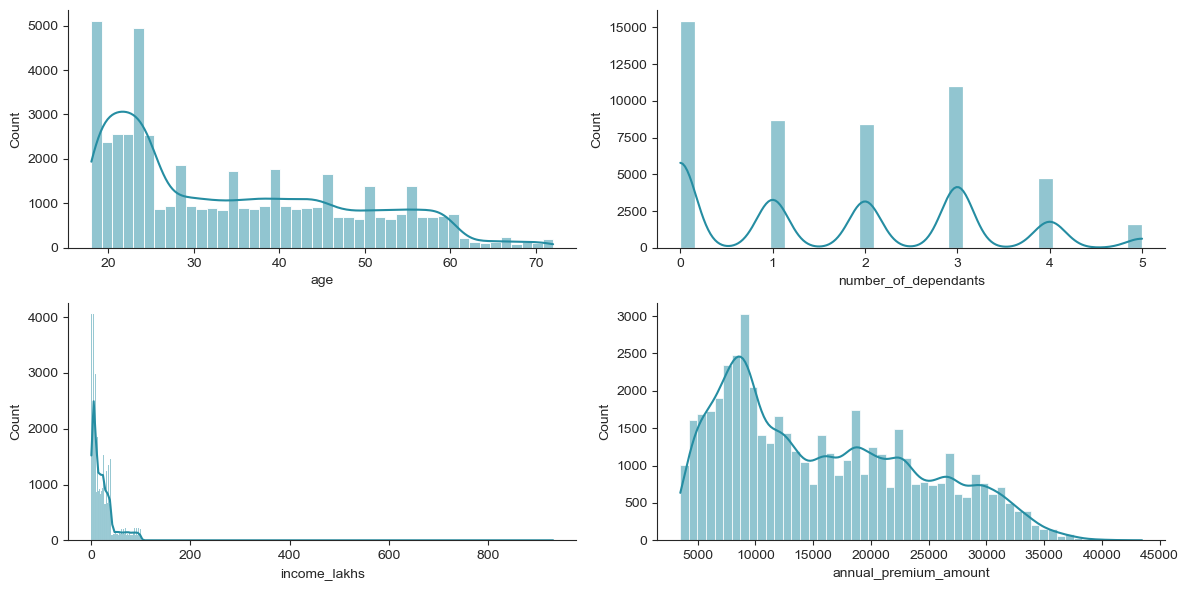

In [214]:
#distribution plot with outliers

plt.figure(figsize=(12, 6))

ncols = 2
nrows = math.ceil(len(numeric_columns) / ncols)

for i, col in enumerate(numeric_columns, start=1):
    plt.subplot(nrows, ncols, i)
    sns.histplot(x=data[col], color="#258DA2", kde= True)
    
    
plt.tight_layout()
sns.despine()
plt.show()



In [215]:
# Outlier Treatment for income_lakhs column
# Using an IQR method to solve outlier problem

data['income_lakhs'].describe()


count    49918.000000
mean        23.025141
std         24.227912
min          1.000000
25%          7.000000
50%         17.000000
75%         31.000000
max        930.000000
Name: income_lakhs, dtype: float64

In [216]:
#quantile
Q1, Q3 = data['income_lakhs'].quantile([0.25, 0.75])
Q1, Q3

(7.0, 31.0)

In [217]:
def get_iqr_bounds(col):
    Q1, Q3 = col.quantile([0.25, 0.75])
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return lower_bound, upper_bound


In [218]:
get_iqr_bounds(data['income_lakhs'])

(-29.0, 67.0)

- 67 LPA is okay but can I use it as my upperbound
- Try bunch of other methods

In [219]:
data['income_lakhs'].quantile(0.999)

100.0

In [220]:
qunatile_threshhold = data['income_lakhs'].quantile(0.999)
qunatile_threshhold

100.0

1 Cr income is okay when we use upper bound as 0.999

In [221]:
print("Observations that has income more than threshold i.e 1 Cr: ")
data[data['income_lakhs'] > qunatile_threshhold]


Observations that has income more than threshold i.e 1 Cr: 


,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
2635,51,Male,Northwest,Married,4,Obesity,No Smoking,Self-Employed,> 40L,560,High blood pressure,Gold,30692
4220,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,> 40L,440,No Disease,Silver,10636
7775,35,Female,Northeast,Unmarried,0,Overweight,No Smoking,Salaried,> 40L,630,Diabetes,Gold,24010
9021,43,Male,Southeast,Married,3,Obesity,Regular,Salaried,> 40L,900,Diabetes & Thyroid,Gold,30848
10337,37,Female,Southeast,Married,3,Normal,No Smoking,Freelancer,> 40L,930,Diabetes,Silver,15945
10639,20,Female,Southwest,Unmarried,0,Normal,No Smoking,Freelancer,> 40L,580,Thyroid,Silver,12888
11456,21,Female,Southwest,Unmarried,0,Obesity,No Smoking,Freelancer,> 40L,700,No Disease,Bronze,7424
15437,21,Female,Southeast,Unmarried,0,Normal,Occasional,Salaried,> 40L,790,No Disease,Silver,7586
35446,59,Male,Northwest,Married,2,Obesity,Occasional,Self-Employed,> 40L,770,Thyroid,Gold,31115
40970,48,Male,Northeast,Married,4,Obesity,No Smoking,Salaried,> 40L,680,No Disease,Gold,28926


In [222]:
print(f"Number of such observations: {data[data['income_lakhs'] > qunatile_threshhold].shape}")

Number of such observations: (10, 13)


In [223]:
# drop those columns that has income > 1 Cr
# do reverse condition
data = data[data['income_lakhs'] <= qunatile_threshhold]
data["income_lakhs"].describe()

count    49908.000000
mean        22.889897
std         22.170699
min          1.000000
25%          7.000000
50%         17.000000
75%         31.000000
max        100.000000
Name: income_lakhs, dtype: float64

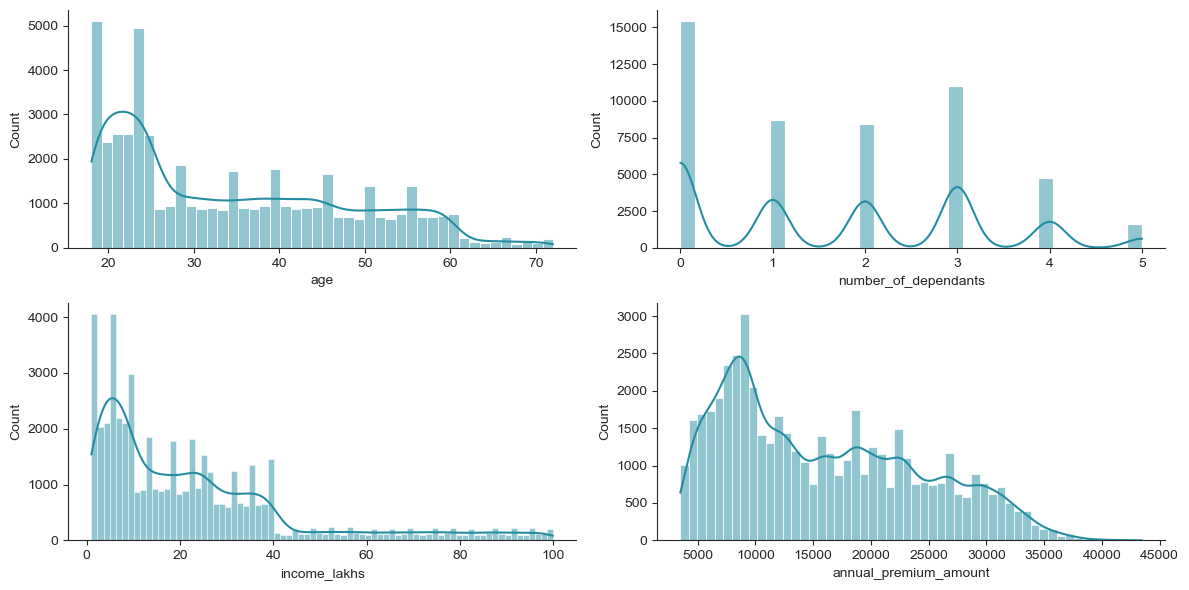

In [224]:
#distribution plot after removal of outliers

plt.figure(figsize=(12, 6))

ncols = 2
nrows = math.ceil(len(numeric_columns) / ncols)

for i, col in enumerate(numeric_columns, start=1):
    plt.subplot(nrows, ncols, i)
    sns.histplot(x=data[col], color="#258DA2", kde= True)
    
    
plt.tight_layout()
sns.despine()
plt.show()

#### 2. Bivariate Analysis - numeric


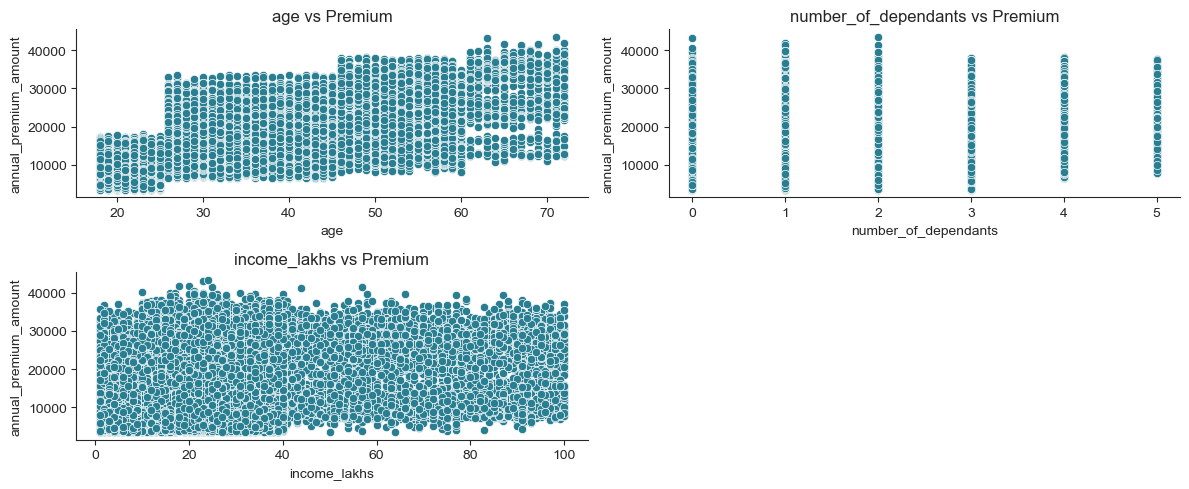

In [225]:

# Scatter plots: numeric vs target
scatter_cols = numeric_columns.drop('annual_premium_amount')

plt.figure(figsize=(12, 5))

ncols = 2
nrows = math.ceil(len(scatter_cols) / ncols)

for i, col in enumerate(scatter_cols, start=1):
    plt.subplot(nrows, ncols, i)
    sns.scatterplot(data=data, x=col, y='annual_premium_amount', color="#297F91")
    plt.title(f"{col} vs Premium")

plt.tight_layout()
sns.despine()
plt.show()


#### Categorical Columns

In [226]:
categorical_cols = data.select_dtypes('object').columns
categorical_cols

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status', 'income_level', 'medical_history',
       'insurance_plan'],
      dtype='object')

In [227]:
for col in categorical_cols:
    print(col, ":", data[col].unique())

gender : ['Male' 'Female']
region : ['Northwest' 'Southeast' 'Northeast' 'Southwest']
marital_status : ['Unmarried' 'Married']
bmi_category : ['Normal' 'Obesity' 'Overweight' 'Underweight']
smoking_status : ['No Smoking' 'Regular' 'Occasional' 'Smoking=0' 'Does Not Smoke'
 'Not Smoking']
employment_status : ['Salaried' 'Self-Employed' 'Freelancer']
income_level : ['<10L' '10L - 25L' '> 40L' '25L - 40L']
medical_history : ['Diabetes' 'High blood pressure' 'No Disease'
 'Diabetes & High blood pressure' 'Thyroid' 'Heart disease'
 'High blood pressure & Heart disease' 'Diabetes & Thyroid'
 'Diabetes & Heart disease']
insurance_plan : ['Bronze' 'Silver' 'Gold']


There is clearly some data inconsistency in smoking status


In [228]:
#make value consistent
data['smoking_status'] = data['smoking_status'].replace({
    'Smoking=0' : 'No Smoking',
    'Does Not Smoke': 'No Smoking',
    'Not Smoking': 'No Smoking'
})

data['smoking_status'].unique()

array(['No Smoking', 'Regular', 'Occasional'], dtype=object)

#### Summary Stats

In [229]:
data.select_dtypes('object').describe().T

,count,unique,top,freq
gender,49908,2,Male,27431
region,49908,4,Southeast,17487
marital_status,49908,2,Unmarried,25630
bmi_category,49908,4,Normal,23469
smoking_status,49908,3,No Smoking,27343
employment_status,49908,3,Salaried,20932
income_level,49908,4,<10L,18643
medical_history,49908,9,No Disease,21138
insurance_plan,49908,3,Bronze,21545


####  Univariate Analysis - categorical

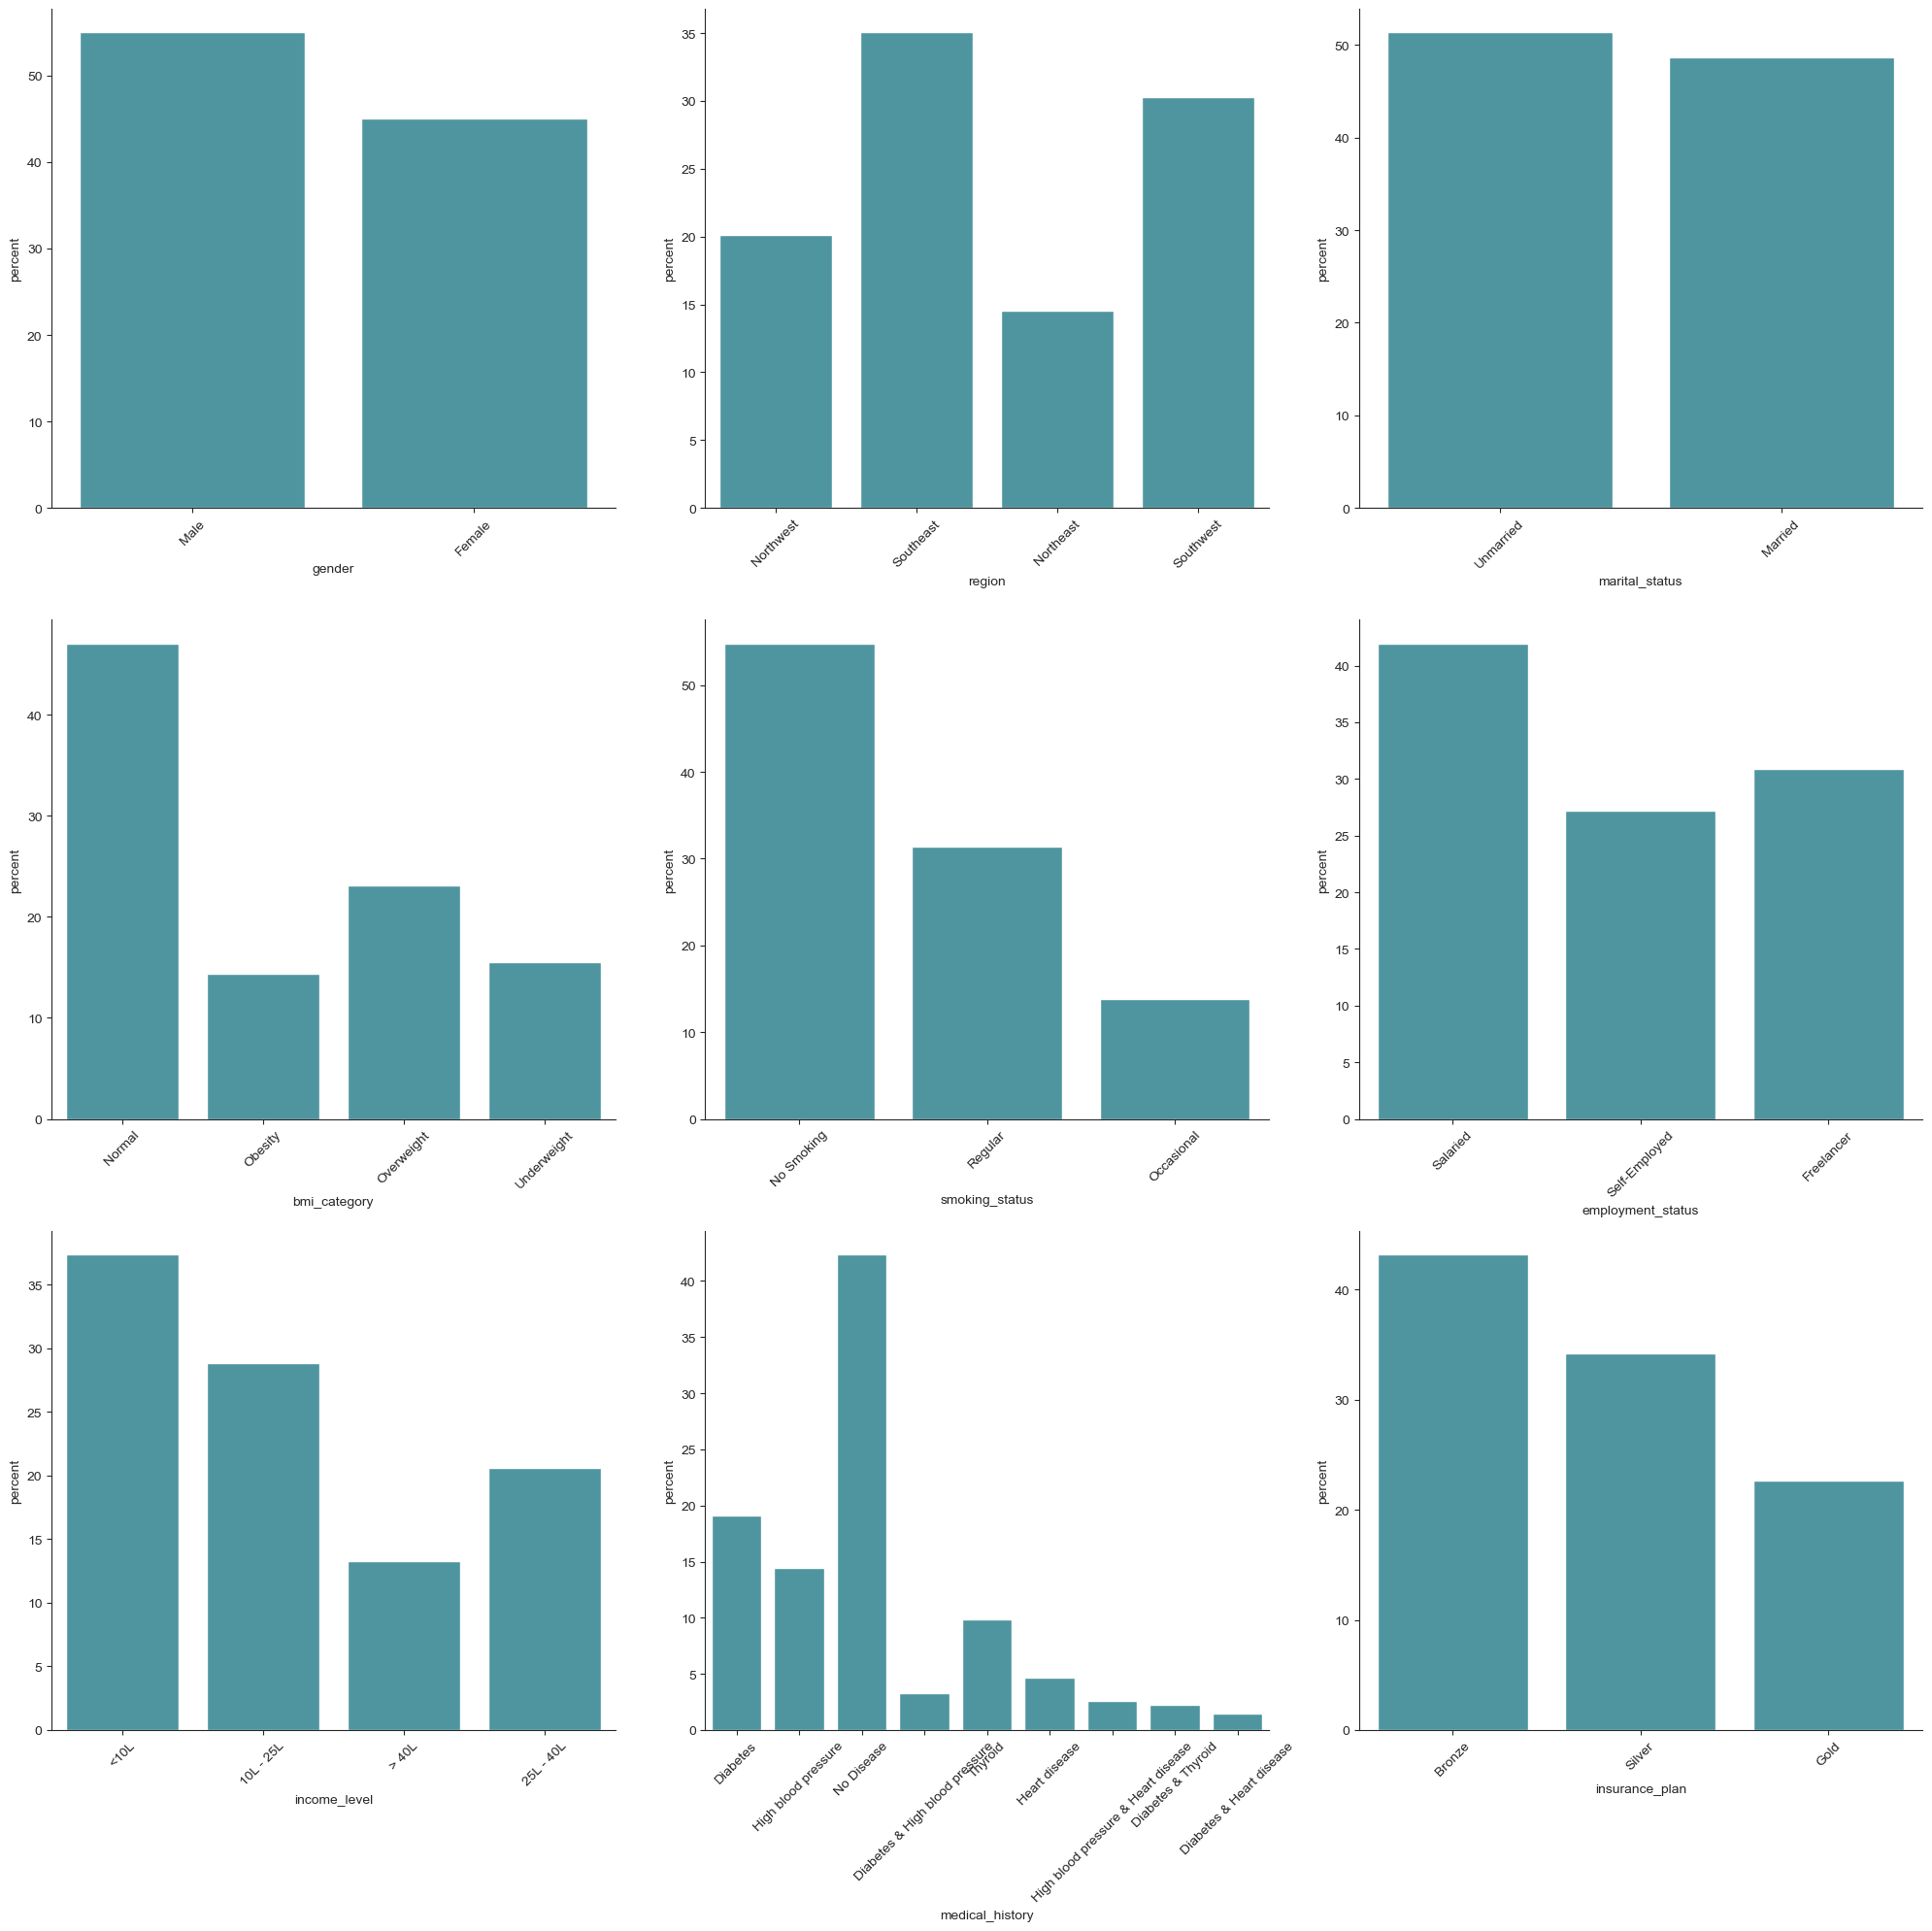

In [230]:
plt.figure(figsize=(20, 20))

ncols = 3
nrows = math.ceil(len(categorical_cols) / ncols)

for i, col in enumerate(categorical_cols, start=1):
    plt.subplot(nrows, ncols, i)
    sns.countplot(data=data, x=col, color="#409FAD", stat='percent')
    plt.xticks(rotation=45)

plt.tight_layout()
sns.despine()
plt.show()


#### Bivariate Analysis - categorical


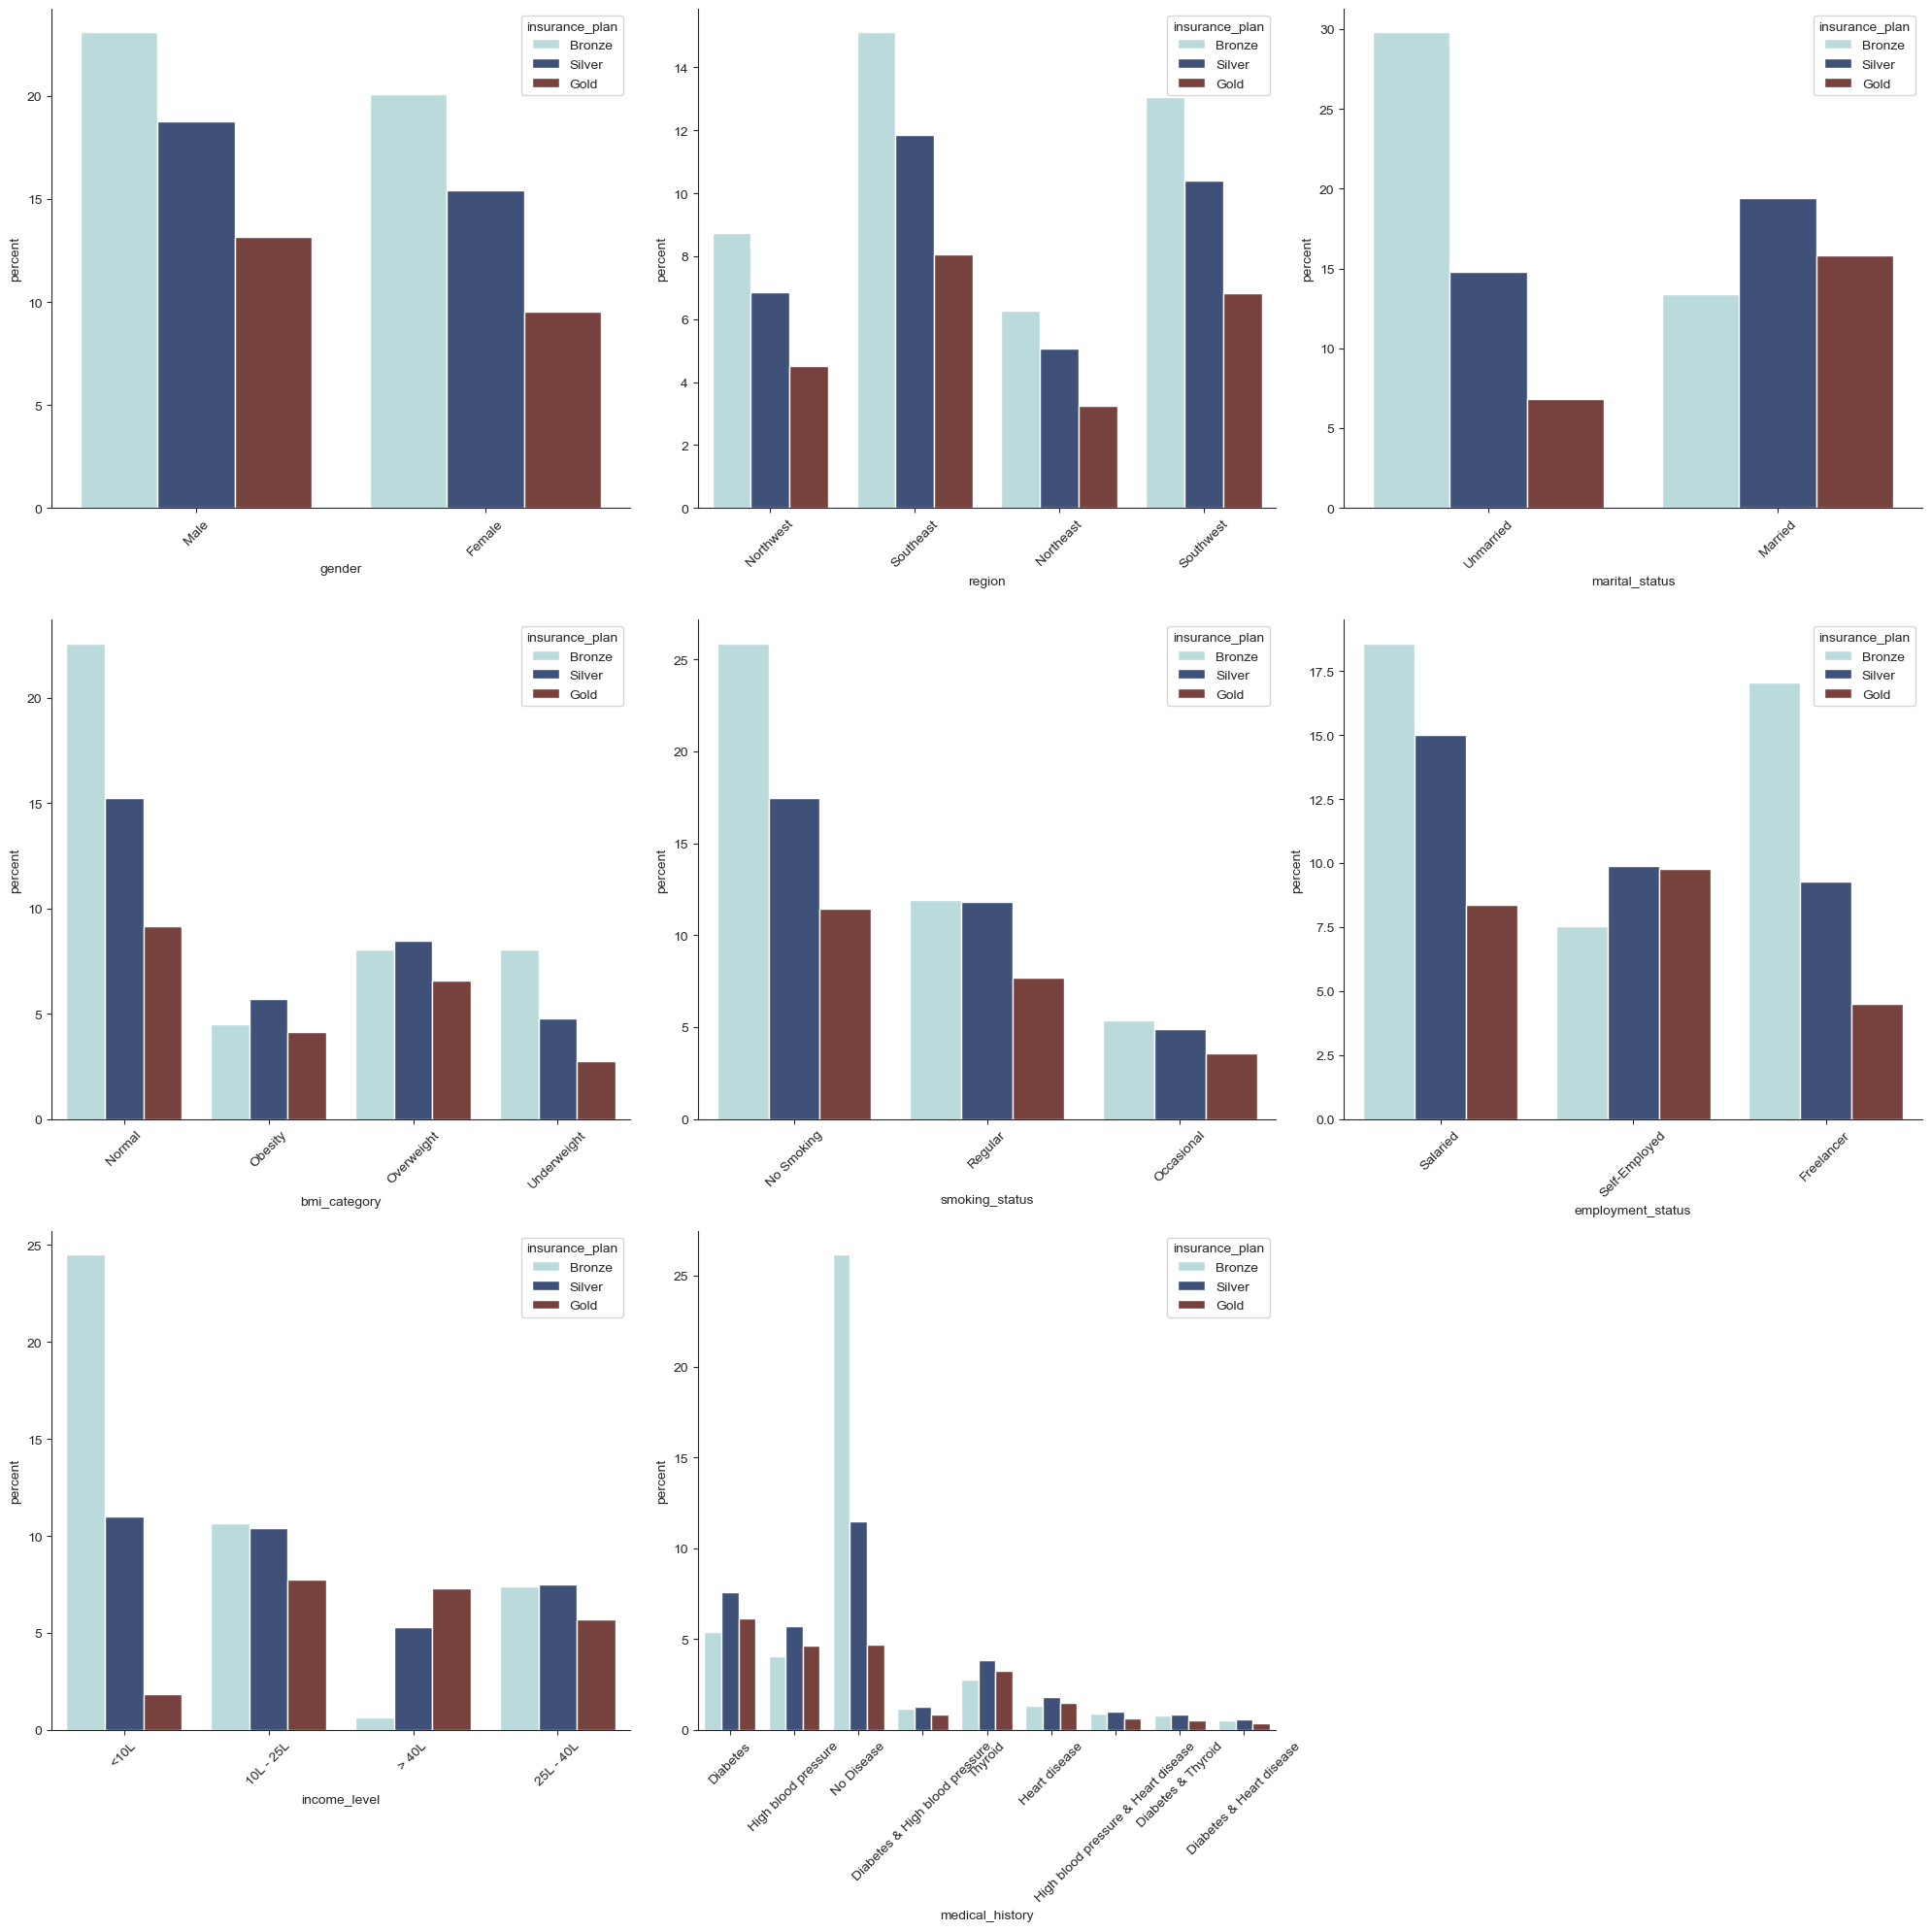

In [231]:
plt.figure(figsize=(20, 20))
sns.set_style('ticks')

ncols = 3
nrows = math.ceil(len(categorical_cols) / ncols)
Palette = ["#B5DFE2", "#354E83", "#803835"]

for i, col in enumerate(categorical_cols.drop('insurance_plan'), start=1):
    plt.subplot(nrows, ncols, i)
    sns.countplot(data=data, x=col, color="#409FAD", stat='percent', hue= data['insurance_plan'], palette= Palette)
    plt.xticks(rotation=45)

plt.tight_layout()
sns.despine()
plt.show()


<h3  style = "color: skyblue">Feature Engineering</h3>

1. Feature Construction
2. Feature Transformation
3. Feature Selection

#### 1. Feature Construction

In [232]:
data.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365


In [233]:
data['medical_history'].unique()

array(['Diabetes', 'High blood pressure', 'No Disease',
       'Diabetes & High blood pressure', 'Thyroid', 'Heart disease',
       'High blood pressure & Heart disease', 'Diabetes & Thyroid',
       'Diabetes & Heart disease'], dtype=object)

In [234]:
# Define the risk scores for each condition

risk_scores = {
    "diabetes": 6,
    "heart disease": 8,
    "high blood pressure":6,
    "thyroid": 5,
    "no disease": 0,
    "none":0
}


In [235]:
#sep each diseases, make dataframe, and make each case lower
data[['disease1', 'disease2']] = data['medical_history'].str.split("&", expand= True).apply( lambda x:x.str.lower().str.strip())

data.sample(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2
49478,20,Female,Southwest,Unmarried,1,Normal,Occasional,Freelancer,10L - 25L,17,Diabetes,Bronze,6743,diabetes,None
19357,20,Female,Southeast,Married,3,Normal,Regular,Freelancer,25L - 40L,34,No Disease,Bronze,7087,no disease,None
9945,21,Female,Southwest,Unmarried,0,Overweight,No Smoking,Self-Employed,10L - 25L,11,No Disease,Bronze,4855,no disease,None
33252,18,Female,Southwest,Unmarried,1,Underweight,No Smoking,Freelancer,10L - 25L,17,No Disease,Bronze,6588,no disease,None
19601,25,Male,Northwest,Unmarried,1,Normal,Occasional,Self-Employed,10L - 25L,18,No Disease,Silver,12329,no disease,None


In [236]:
data['disease1'] = data['disease1'].fillna('none')
data['disease2'] = data['disease1'].fillna('none')

data['total_risk_scores'] = 0

In [237]:
data.sample(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_scores
19554,43,Female,Northwest,Married,5,Obesity,No Smoking,Freelancer,<10L,4,High blood pressure & Heart disease,Bronze,17408,high blood pressure,high blood pressure,0
42074,18,Female,Southwest,Unmarried,1,Normal,No Smoking,Salaried,10L - 25L,13,High blood pressure,Gold,12464,high blood pressure,high blood pressure,0
5604,53,Female,Northeast,Married,2,Normal,No Smoking,Salaried,<10L,9,High blood pressure,Silver,18341,high blood pressure,high blood pressure,0
11070,42,Female,Southwest,Unmarried,1,Normal,No Smoking,Self-Employed,<10L,5,High blood pressure,Bronze,9334,high blood pressure,high blood pressure,0
10784,32,Male,Northwest,Married,3,Underweight,No Smoking,Self-Employed,<10L,9,High blood pressure & Heart disease,Bronze,13464,high blood pressure,high blood pressure,0


In [238]:
for disease in ['disease1', 'disease2']:
    data['total_risk_scores'] += data[disease].map(risk_scores)

data.sample(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_scores
13253,36,Female,Northeast,Married,3,Obesity,No Smoking,Salaried,<10L,3,No Disease,Bronze,11418,no disease,no disease,0
18355,21,Female,Northeast,Unmarried,1,Obesity,No Smoking,Freelancer,<10L,1,No Disease,Gold,14960,no disease,no disease,0
10657,43,Female,Southeast,Married,4,Normal,Occasional,Salaried,<10L,8,High blood pressure,Bronze,10297,high blood pressure,high blood pressure,12
20394,20,Male,Northwest,Unmarried,0,Underweight,No Smoking,Salaried,25L - 40L,39,No Disease,Bronze,4046,no disease,no disease,0
38553,35,Female,Southeast,Married,3,Overweight,No Smoking,Salaried,> 40L,54,High blood pressure,Silver,17655,high blood pressure,high blood pressure,12


#### 2. Feature Transformation

1. Label Encoding : `Ordinal Data`
2. One Hot Encoding: `Nominal Data`
3. Feature Scaling

Label Encoding for Ordinal Data

In [239]:
#For insurnace plan
#can do label encoding since it is ordinal data
data['insurance_plan'] = data['insurance_plan'].map({
    'Bronze': 1,
    'Silver': 2,
    'Gold': 3
})

data['insurance_plan'].unique()

array([1, 2, 3], dtype=int64)

In [240]:
#similarly for income_level we can do Label encoding
data['income_level'].unique()

array(['<10L', '10L - 25L', '> 40L', '25L - 40L'], dtype=object)

In [241]:
data['income_level'] = data['income_level'].map({
    '<10L': 1,
    '10L - 25L': 2,
    '25L - 40L': 3,
    '> 40L': 4
})

data['income_level'].unique()

array([1, 2, 4, 3], dtype=int64)

One Hot Encoding for Nominal Data

In [242]:
data.select_dtypes('object').columns

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status', 'medical_history', 'disease1', 'disease2'],
      dtype='object')

In [243]:
nominal_cols = ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status']

data_v1 = pd.get_dummies(data=data, columns= nominal_cols, drop_first= True, dtype='int')
data_v1.head()

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_scores,...,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,Diabetes,1,9053,diabetes,diabetes,12,...,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,Diabetes,1,16339,diabetes,diabetes,12,...,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,High blood pressure,2,18164,high blood pressure,high blood pressure,12,...,0,0,0,0,0,0,0,0,0,1
3,30,3,4,77,No Disease,3,20303,no disease,no disease,0,...,1,0,0,0,0,0,0,0,1,0
4,18,0,4,99,High blood pressure,2,13365,high blood pressure,high blood pressure,12,...,0,0,1,0,1,0,0,1,0,1


Feature Scaling

In [244]:
#Use MinMaxScaler
cols_to_scale = ['age', 'number_of_dependants', 'income_level',	'income_lakhs',	'insurance_plan', 'total_risk_scores']

scaler = MinMaxScaler()
data_v1[cols_to_scale] = scaler.fit_transform(data_v1[cols_to_scale])
data_v1.head()

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_scores,...,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.148148,0.0,0.000000,0.050505,Diabetes,0.0,9053,diabetes,diabetes,0.75,...,0,0,1,0,0,0,0,0,1,0
1,0.203704,0.4,0.000000,0.050505,Diabetes,0.0,16339,diabetes,diabetes,0.75,...,1,0,0,1,0,0,0,1,1,0
2,0.574074,0.4,0.333333,0.191919,High blood pressure,0.5,18164,high blood pressure,high blood pressure,0.75,...,0,0,0,0,0,0,0,0,0,1
3,0.222222,0.6,1.000000,0.767677,No Disease,1.0,20303,no disease,no disease,0.00,...,1,0,0,0,0,0,0,0,1,0
4,0.000000,0.0,1.000000,0.989899,High blood pressure,0.5,13365,high blood pressure,high blood pressure,0.75,...,0,0,1,0,1,0,0,1,0,1


#### 3. Feature Selection

1. Business understanding

2. Statistical Techniques:
      - Filtered-based : correlation matrix
      - Embedded method

In [245]:
data_v1.columns

Index(['age', 'number_of_dependants', 'income_level', 'income_lakhs',
       'medical_history', 'insurance_plan', 'annual_premium_amount',
       'disease1', 'disease2', 'total_risk_scores', 'gender_Male',
       'region_Northwest', 'region_Southeast', 'region_Southwest',
       'marital_status_Unmarried', 'bmi_category_Obesity',
       'bmi_category_Overweight', 'bmi_category_Underweight',
       'smoking_status_Occasional', 'smoking_status_Regular',
       'employment_status_Salaried', 'employment_status_Self-Employed'],
      dtype='object')

In [246]:
#Dropping some columns that is not necessary
data_v1 = data_v1.drop(columns=['medical_history', 'disease1', 'disease2'])
data_v1.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,total_risk_scores,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.148148,0.0,0.000000,0.050505,0.0,9053,0.75,1,1,0,0,1,0,0,0,0,0,1,0
1,0.203704,0.4,0.000000,0.050505,0.0,16339,0.75,0,0,1,0,0,1,0,0,0,1,1,0
2,0.574074,0.4,0.333333,0.191919,0.5,18164,0.75,0,0,0,0,0,0,0,0,0,0,0,1
3,0.222222,0.6,1.000000,0.767677,1.0,20303,0.00,0,0,1,0,0,0,0,0,0,0,1,0
4,0.000000,0.0,1.000000,0.989899,0.5,13365,0.75,1,0,0,0,1,0,1,0,0,1,0,1


#### 1. Filtered-based method

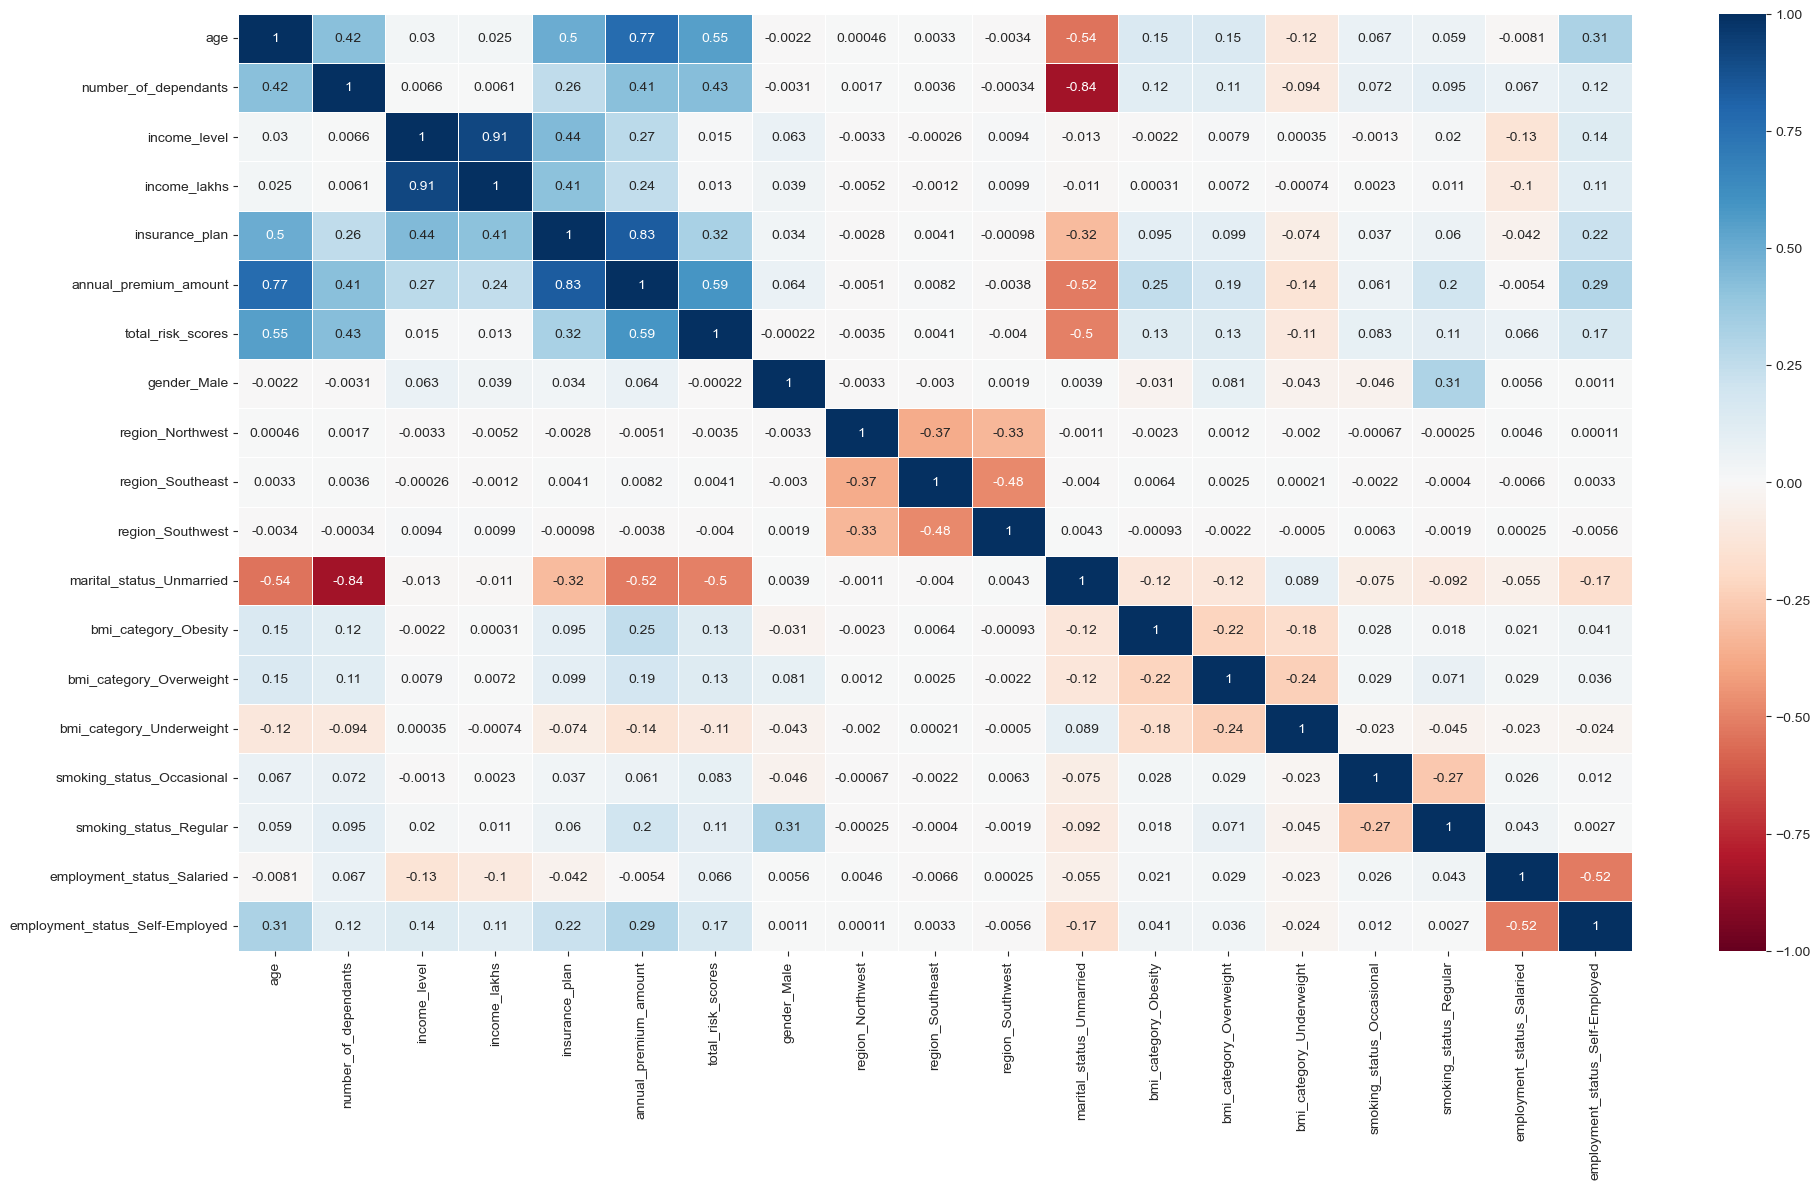

In [247]:
#Correlation matrix
cm = data_v1.corr()

plt.figure(figsize=(20,12))
sns.set_style('ticks')

sns.heatmap(cm, annot= True, vmin= -1, vmax=1, cmap="RdBu", linewidths=0.7)
plt.tight_layout()
plt.show()

Strong multicollinearity: (income_level, income_lakhs) and (insurance_plan, annual_premium_amount) are highly correlated.

Marital status effects: Unmarried is strongly negatively related to age, dependants, and premium.

##### Calculate VIF for Multicolinearity

In [248]:
data_v1.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,total_risk_scores,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.148148,0.0,0.000000,0.050505,0.0,9053,0.75,1,1,0,0,1,0,0,0,0,0,1,0
1,0.203704,0.4,0.000000,0.050505,0.0,16339,0.75,0,0,1,0,0,1,0,0,0,1,1,0
2,0.574074,0.4,0.333333,0.191919,0.5,18164,0.75,0,0,0,0,0,0,0,0,0,0,0,1
3,0.222222,0.6,1.000000,0.767677,1.0,20303,0.00,0,0,1,0,0,0,0,0,0,0,1,0
4,0.000000,0.0,1.000000,0.989899,0.5,13365,0.75,1,0,0,0,1,0,1,0,0,1,0,1


In [249]:
X = data_v1.drop(columns=['annual_premium_amount'])
y = data_v1['annual_premium_amount']

In [250]:
X.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,total_risk_scores,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.148148,0.0,0.000000,0.050505,0.0,0.75,1,1,0,0,1,0,0,0,0,0,1,0
1,0.203704,0.4,0.000000,0.050505,0.0,0.75,0,0,1,0,0,1,0,0,0,1,1,0
2,0.574074,0.4,0.333333,0.191919,0.5,0.75,0,0,0,0,0,0,0,0,0,0,0,1
3,0.222222,0.6,1.000000,0.767677,1.0,0.00,0,0,1,0,0,0,0,0,0,0,1,0
4,0.000000,0.0,1.000000,0.989899,0.5,0.75,1,0,0,0,1,0,1,0,0,1,0,1


In [251]:
y[:5]

0     9053
1    16339
2    18164
3    20303
4    13365
Name: annual_premium_amount, dtype: int64

In [252]:
def calculate_vif(X):
    vif_df = pd.DataFrame()
    vif_df['Columns'] = X.columns
    vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range (X.shape[1])] 

    return vif_df

In [253]:
calculate_vif(X)

,Columns,VIF
0,age,4.897567
1,number_of_dependants,4.563780
2,income_level,12.449385
3,income_lakhs,11.182932
4,insurance_plan,3.588919
5,total_risk_scores,3.644133
6,gender_Male,2.421488
7,region_Northwest,2.103369
8,region_Southeast,2.923840
9,region_Southwest,2.670962


In [254]:
#we will drop income_lakhs due to high VIF value
X = X.drop(columns=['income_level'])

In [255]:
#recalculating VIF

calculate_vif(X)

,Columns,VIF
0,age,4.877116
1,number_of_dependants,4.555145
2,income_lakhs,2.480489
3,insurance_plan,3.449423
4,total_risk_scores,3.644125
5,gender_Male,2.409978
6,region_Northwest,2.101554
7,region_Southeast,2.921116
8,region_Southwest,2.668533
9,marital_status_Unmarried,3.394591


In [256]:
X.shape

(49908, 17)

<h3  style = "color: skyblue" >Modeling<h3>


Hold-out approach

In [257]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.30, random_state=10)

# shape of the X_train, X_test, y_train, y_test features
print("x train:", X_train.shape)
print("y train:", y_train.shape)
print("y train:", X_test.shape)
print("y test:", y_test.shape)

x train: (34935, 17)
y train: (34935,)
y train: (14973, 17)
y test: (14973,)


Base Model: Linear Regression

In [258]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

LinearRegression()

In [259]:
y_pred = model_lr.predict(X_test)
print(f"MSE: {mean_squared_error(y_test, y_pred)}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred)}")
print(f"R2 Score: {r2_score(y_test, y_pred)}")

MSE: 5388185.513909681
RMSE: 2321.246543112058
R2 Score: 0.9249547767553817


Cross validation appraoch

In [260]:
kfold = KFold(n_splits=5, shuffle= True, random_state=42)

scores = cross_val_score(estimator = model_lr, X= X, y= y, cv=kfold, scoring='r2')

print("R2 scores for each folds:", scores)
print("Mean R2 score across all folds:", np.mean(scores))

R2 scores for each folds: [0.92371215 0.9260673  0.92444087 0.92409737 0.92564855]
Mean R2 score across all folds: 0.9247932499608706


In [261]:
model_lr.intercept_

4841.007194459322

In [262]:
model_lr.coef_

array([10636.72523772,  -691.83324098,  -483.48168713, 12522.25545078,
        3673.01123543,   167.6352943 ,   -41.47118922,    36.80827576,
         -15.2265781 ,  -924.46940308,  3341.03669516,  1575.99166466,
         408.34662847,   724.55892   ,  2215.99670713,   134.18710377,
         406.64583591])

In [263]:
feature_importance = model_lr.coef_
feature_importance_df = pd.DataFrame(feature_importance, columns= ['Coefficients'], index= X_test.columns)
feature_importance_df_sorted = feature_importance_df.sort_values(by='Coefficients')
feature_importance_df_sorted

,Coefficients
marital_status_Unmarried,-924.469403
number_of_dependants,-691.833241
income_lakhs,-483.481687
region_Northwest,-41.471189
region_Southwest,-15.226578
region_Southeast,36.808276
employment_status_Salaried,134.187104
gender_Male,167.635294
employment_status_Self-Employed,406.645836
bmi_category_Underweight,408.346628


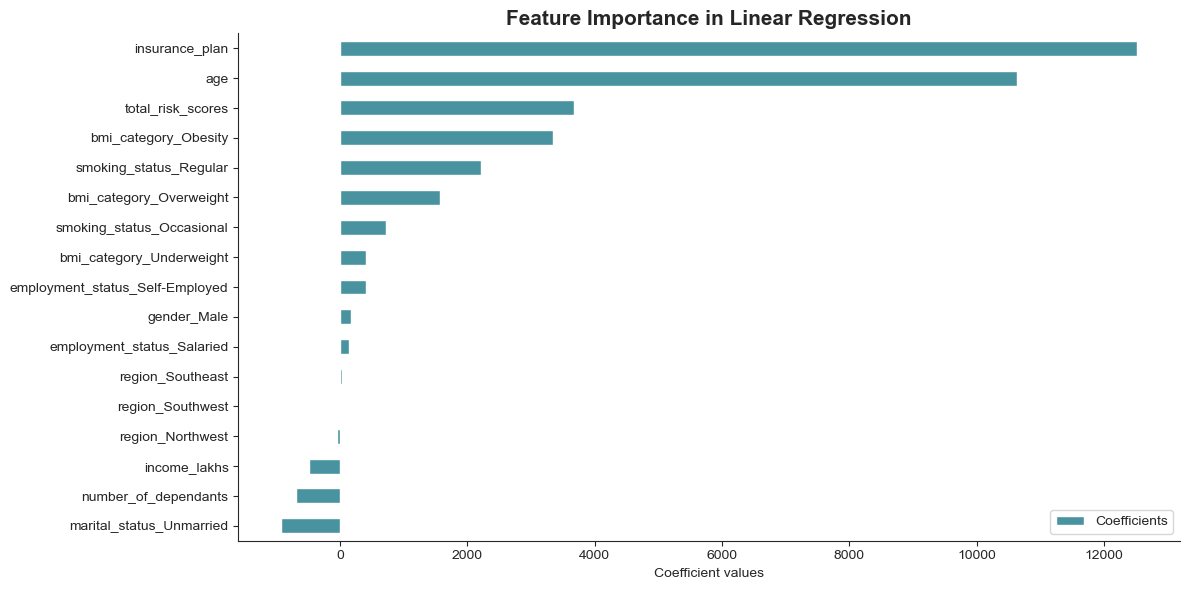

In [264]:
feature_importance_df_sorted.plot(kind='barh', color= "#48939F", figsize=(12,6))
plt.title("Feature Importance in Linear Regression", fontsize = 15, fontweight = 'bold')
plt.xlabel("Coefficient values")
sns.despine()
plt.tight_layout()
plt.show()

Ridge Regression Model

In [265]:
model_rg = Ridge()
model_rg.fit(X_train, y_train)

Ridge()

In [266]:
y_pred = model_rg.predict(X_test)
print(f"MSE: {mean_squared_error(y_test, y_pred)}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred)}")
print(f"R2 Score: {r2_score(y_test, y_pred)}")

MSE: 5388207.512484995
RMSE: 2321.251281633463
R2 Score: 0.9249544703650411


Lasso Regression Model

In [267]:
model_la = Lasso()
model_la.fit(X_train, y_train)

Lasso()

In [268]:
y_pred = model_la.predict(X_test)
print(f"MSE: {mean_squared_error(y_test, y_pred)}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred)}")
print(f"R2 Score: {r2_score(y_test, y_pred)}")

MSE: 5385991.177181293
RMSE: 2320.773831544404
R2 Score: 0.9249853388971697


In [269]:
model_la.intercept_

4813.027958431365

In [270]:
model_la.coef_

array([ 1.06368955e+04, -6.32374594e+02, -4.55711698e+02,  1.25124251e+04,
        3.67295527e+03,  1.64667133e+02, -3.02172557e+01,  4.03054618e+01,
       -5.77338834e+00, -8.96540101e+02,  3.32897255e+03,  1.56713887e+03,
        3.95569053e+02,  7.14282530e+02,  2.21028568e+03,  1.27415793e+02,
        3.99564294e+02])

In [271]:
feature_importance = model_la.coef_
feature_importance_df = pd.DataFrame(feature_importance, columns= ['Coefficients'], index= X_test.columns)
feature_importance_df_sorted = feature_importance_df.sort_values(by='Coefficients')
feature_importance_df_sorted

,Coefficients
marital_status_Unmarried,-896.540101
number_of_dependants,-632.374594
income_lakhs,-455.711698
region_Northwest,-30.217256
region_Southwest,-5.773388
region_Southeast,40.305462
employment_status_Salaried,127.415793
gender_Male,164.667133
bmi_category_Underweight,395.569053
employment_status_Self-Employed,399.564294


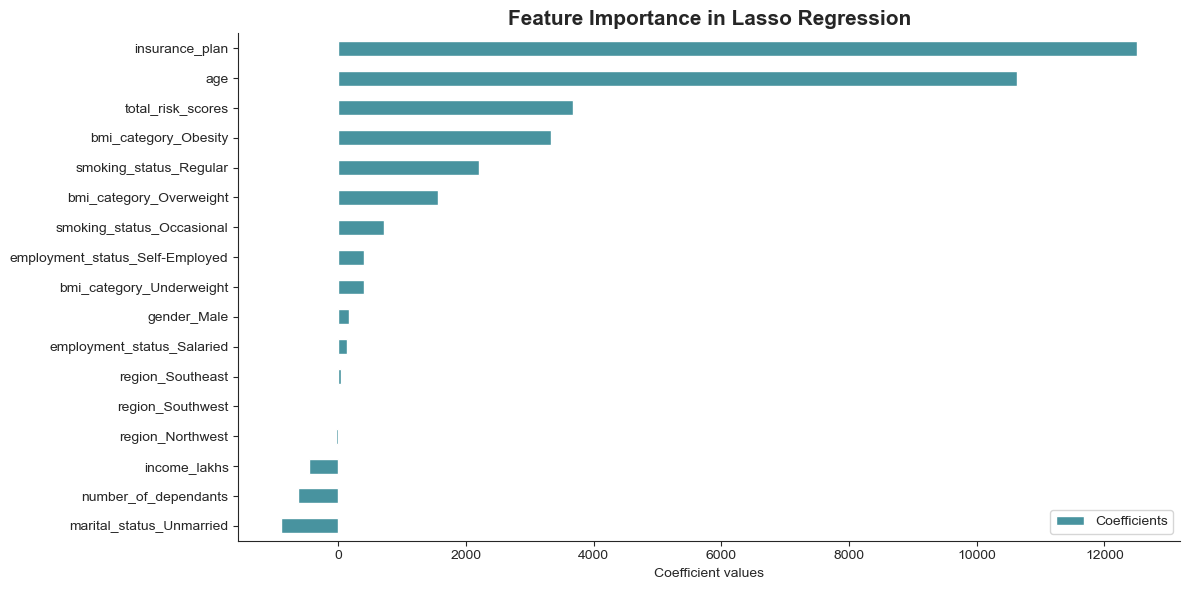

In [272]:
feature_importance_df_sorted.plot(kind='barh', color= "#48939F", figsize=(12,6))
plt.title("Feature Importance in Lasso Regression", fontsize = 15, fontweight = 'bold')
plt.xlabel("Coefficient values")
sns.despine()
plt.tight_layout()
plt.show()

XGBoost : XGBRegressor Model

In [273]:
model_xgb = XGBRegressor()
model_xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [274]:
y_pred = model_xgb.predict(X_test)
print(f"MSE: {mean_squared_error(y_test, y_pred)}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred)}")
print(f"R2 Score: {r2_score(y_test, y_pred)}")

MSE: 1918967.243895698
RMSE: 1385.2679321689714
R2 Score: 0.9732731315865981


#### Hyparameter Tuning: XGBRegressor

1. Grid Search CV
2. Randomizedsearch CV

In [275]:
#Gridsearch cv
model_xgb = XGBRegressor()

param_grid = {
    'n_estimators': [20, 40, 50],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5]
}

gscv = GridSearchCV(estimator= model_xgb, param_grid= param_grid, scoring='r2', refit= True, cv= kfold, verbose=2)

#fit the training data
gscv.fit(X_train, y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV] END ...learning_rate=0.01, max_depth=3, n_estimators=20; total time=   0.0s
[CV] END ...learning_rate=0.01, max_depth=3, n_estimators=20; total time=   0.0s
[CV] END ...learning_rate=0.01, max_depth=3, n_estimators=20; total time=   0.0s
[CV] END ...learning_rate=0.01, max_depth=3, n_estimators=20; total time=   0.0s
[CV] END ...learning_rate=0.01, max_depth=3, n_estimators=20; total time=   0.0s
[CV] END ...learning_rate=0.01, max_depth=3, n_estimators=40; total time=   0.0s
[CV] END ...learning_rate=0.01, max_depth=3, n_estimators=40; total time=   0.1s
[CV] END ...learning_rate=0.01, max_depth=3, n_estimators=40; total time=   0.0s
[CV] END ...learning_rate=0.01, max_depth=3, n_estimators=40; total time=   0.0s
[CV] END ...learning_rate=0.01, max_depth=3, n_estimators=40; total time=   0.1s
[CV] END ...learning_rate=0.01, max_depth=3, n_estimators=50; total time=   0.0s
[CV] END ...learning_rate=0.01, max_depth=3, n_

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    inte...
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=None, ...),
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 4, 5], 'n_estimators': [20, 40, 50]},
             scoring='r2', verbose=2)

In [276]:
#print the best parameters and best scores
print(f"Best parameters: {gscv.best_params_}")
print(f"Best Score: {gscv.best_score_}")

#best model
best_model = gscv.best_estimator_

Best parameters: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 40}
Best Score: 0.9736872567141542


In [277]:
#use randomizedsearch cv
param_grid = {
    'n_estimators': [20, 40, 50],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
}

rscv = RandomizedSearchCV(estimator= model_xgb, param_distributions= param_grid, n_iter= 10, cv= kfold, scoring='r2')
rscv.fit(X_train, y_train)

RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          gamma=None, grow_policy=None,
                                          importance_type=Non...
                                          max_cat_threshold=None,
                                          max_cat_to_onehot=None,
                                          max_delta_step=None, max_depth=None,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None,
                                          random_state=None, ...),
                   param_distributions={'learning_rate': [0.01, 0.1, 0.2],
                                        'max_depth': [3, 4, 5],
                                        'n_estimators': [20, 40, 50]},
                   scoring='r2')

In [278]:
#print the best parameters and best scores
print(f"Best parameters: {rscv.best_params_}")
print(f"Best Score: {rscv.best_score_}")

#best model according to randomsearch cv
best_model = rscv.best_estimator_

Best parameters: {'n_estimators': 40, 'max_depth': 5, 'learning_rate': 0.2}
Best Score: 0.9736872567141542


In [279]:
feature_importance = best_model.feature_importances_
feature_importance_df = pd.DataFrame(feature_importance, columns= ['Coefficients'], index= X_test.columns)
feature_importance_df_sorted = feature_importance_df.sort_values(by='Coefficients')
feature_importance_df_sorted

,Coefficients
region_Southwest,0.000140
region_Southeast,0.000158
employment_status_Salaried,0.000160
number_of_dependants,0.000176
region_Northwest,0.000192
income_lakhs,0.000194
employment_status_Self-Employed,0.000207
gender_Male,0.000236
marital_status_Unmarried,0.000705
bmi_category_Underweight,0.000994


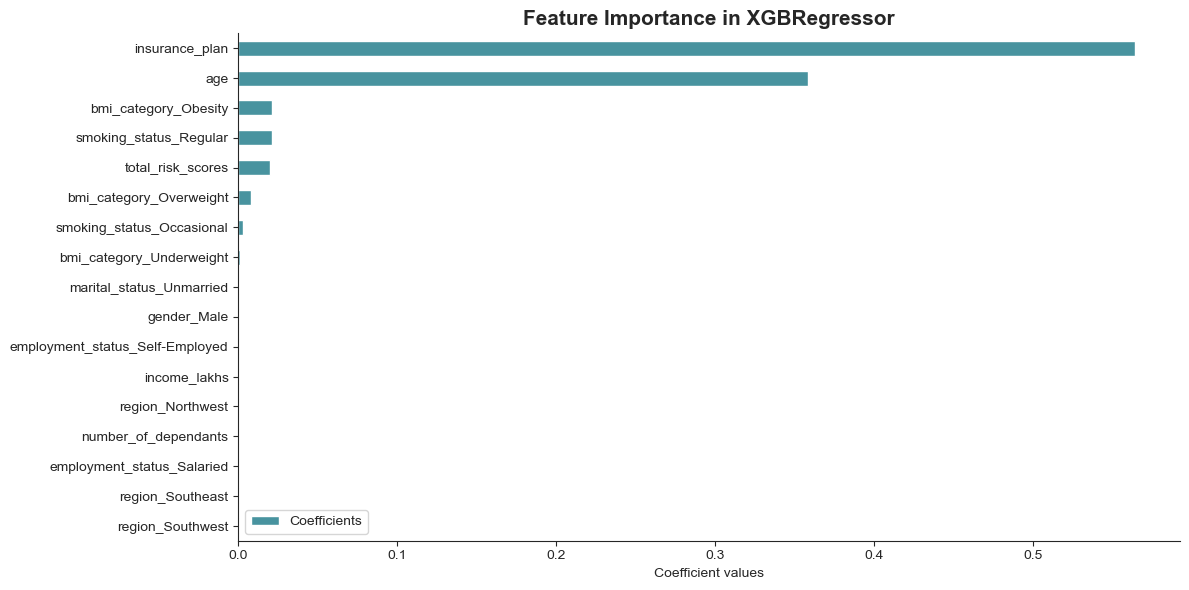

In [280]:
feature_importance_df_sorted.plot(kind='barh', color= "#48939F", figsize=(12,6))
plt.title("Feature Importance in XGBRegressor", fontsize = 15, fontweight = 'bold')
plt.xlabel("Coefficient values")
sns.despine()
plt.tight_layout()
plt.show()

##### R2 metric is not good enough to evaluate the model

#### ERROR ANALYSIS

In [281]:
# Positive residual → model over-predicted
# Negative residual → model under-predicted
# Residual = 0 → perfect prediction

# | Value  | Meaning                                    |
# | ------ | ------------------------------------------ |
# | +20% | Model predicted 20% higher than actual |
# | -10% | Model predicted 10% lower than actual  |
# | 0%   | Perfect prediction                     |


y_pred = best_model.predict(X_test)

residuals = y_pred - y_test
residuals_pct = (residuals * 100) / y_test

results_df = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred,
    'diff': residuals,
    'diff_pct': residuals_pct
})

results_df

,actual,predicted,diff,diff_pct
3598,20554,21000.287109,446.287109,2.171291
35794,29647,29546.789062,-100.210938,-0.338014
43608,20560,20196.630859,-363.369141,-1.767360
42730,5018,7311.461914,2293.461914,45.704701
18936,8929,8009.696777,-919.303223,-10.295702
...,...,...,...,...
5621,18848,19218.681641,370.681641,1.966690
6069,6956,6490.394043,-465.605957,-6.693588
21592,8332,10678.223633,2346.223633,28.159189
49274,5571,6779.455078,1208.455078,21.691888


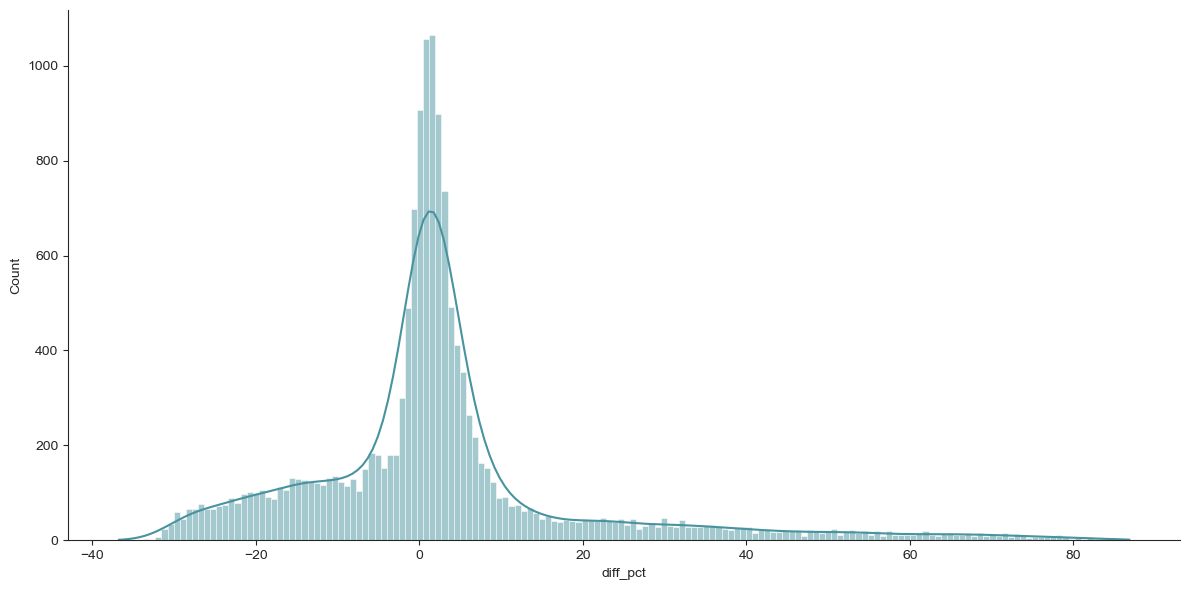

In [282]:
plt.figure(figsize=(12,6))
sns.histplot(results_df['diff_pct'], kde= True, color="#48939F")
sns.despine()
plt.tight_layout()
plt.show()

The distribution of diff_pct is sharply centered around 0%, indicating most predictions are close to the actual values, but it is right-skewed with a long positive tail, showing the model occasionally makes large over-predictions (and fewer extreme under-predictions).

In [283]:
# This dataframe isolates the predictions that are unacceptably inaccurate, based on a 10% error tolerance.
extreme_error_threshold = 10

extreme_result_df = results_df[np.abs(results_df['diff_pct']) > extreme_error_threshold]
extreme_result_df

,actual,predicted,diff,diff_pct
42730,5018,7311.461914,2293.461914,45.704701
18936,8929,8009.696777,-919.303223,-10.295702
20029,5140,6608.016113,1468.016113,28.560625
4294,9631,7086.315918,-2544.684082,-26.421805
44419,4687,6694.231445,2007.231445,42.825506
...,...,...,...,...
8767,8113,6542.124512,-1570.875488,-19.362449
25179,9944,6996.293457,-2947.706543,-29.643067
21592,8332,10678.223633,2346.223633,28.159189
49274,5571,6779.455078,1208.455078,21.691888


In [284]:
extreme_error_pct = extreme_result_df.shape[0] * 100 / results_df.shape[0]
extreme_error_pct

33.894343151005145

About 33.69% of the predictions have errors larger than ±10%, indicating that the model shows limited reliability at this error tolerance level.

In [285]:
results_df[np.abs(results_df['diff_pct'] > 50)].sort_values(by="diff_pct", ascending= False)

,actual,predicted,diff,diff_pct
36269,3501,6542.124512,3041.124512,86.864453
48801,3516,6542.461426,3026.461426,86.076832
42342,3521,6542.124512,3021.124512,85.803025
18564,3523,6530.300293,3007.300293,85.361916
1732,3610,6682.407227,3072.407227,85.108233
...,...,...,...,...
42713,4846,7280.269531,2434.269531,50.232553
11393,4495,6749.174805,2254.174805,50.148494
3766,4516,6779.455078,2263.455078,50.120794
48531,4344,6517.869141,2173.869141,50.043028


<p>Approximately 517 customers are expected to be overcharged or undercharged by more than 50%</p>

##### Root cause of High margin error, ANALYSIS

In [286]:
X_test.index

Index([ 3598, 35794, 43608, 42730, 18936, 45416, 20029,  4294, 39145,  3152,
       ...
        4554,  9086,  8767,   603, 25179,  5621,  6069, 21592, 49274, 27977],
      dtype='int64', length=14973)

In [287]:
extreme_result_df.index

Index([42730, 18936, 20029,  4294, 44419,  6707, 11728, 15740, 35065,  9654,
       ...
        3036, 36158, 21184, 45020,  8249,  8767, 25179, 21592, 49274, 27977],
      dtype='int64', length=5075)

In [288]:
extreme_error_df = X_test.loc[extreme_result_df.index]
extreme_error_df

,age,number_of_dependants,income_lakhs,insurance_plan,total_risk_scores,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
42730,0.092593,0.2,0.131313,0.0,0.75,1,0,0,0,1,0,1,0,0,0,0,0
18936,0.074074,0.0,0.202020,0.0,0.75,1,0,0,1,1,0,1,0,0,1,0,1
20029,0.018519,0.2,0.030303,0.0,0.00,0,1,0,0,1,0,0,1,0,0,1,0
4294,0.000000,0.2,0.020202,0.0,0.00,1,0,0,1,1,0,1,0,0,0,0,0
44419,0.055556,0.0,0.242424,0.0,0.00,0,0,0,0,1,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8767,0.018519,0.2,0.070707,0.0,0.00,0,0,1,0,1,0,0,0,0,0,0,0
25179,0.129630,0.0,0.111111,0.0,0.00,1,0,0,0,1,0,0,0,0,1,0,0
21592,0.055556,0.0,0.060606,0.5,0.00,1,0,0,0,1,0,0,0,0,1,0,0
49274,0.055556,0.2,0.070707,0.0,0.00,0,0,0,0,1,0,0,0,1,0,0,0


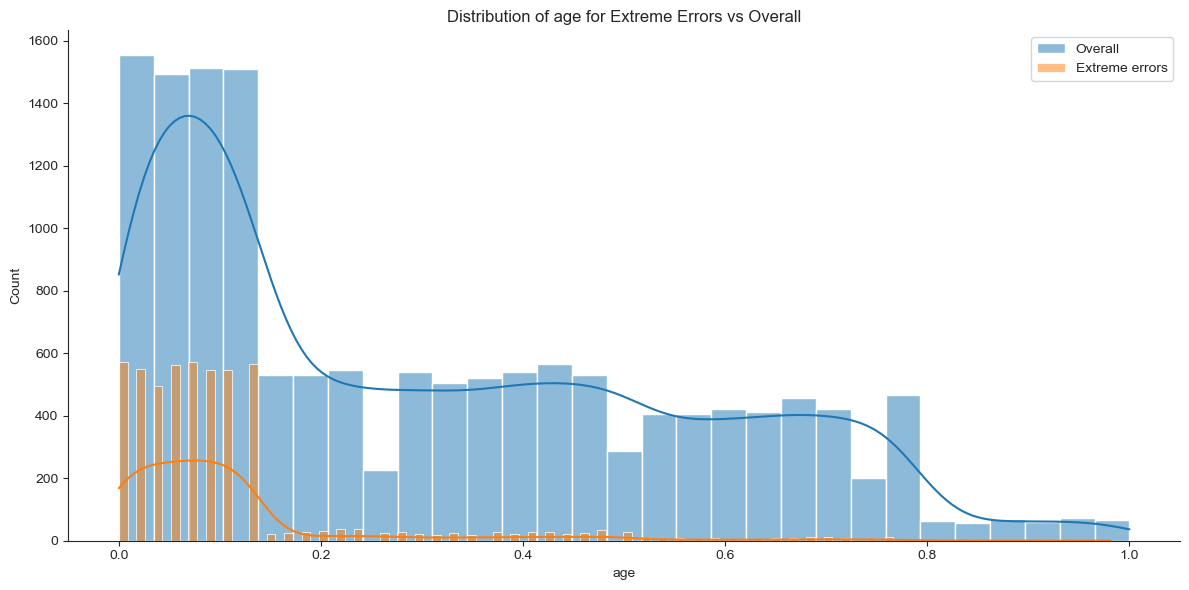

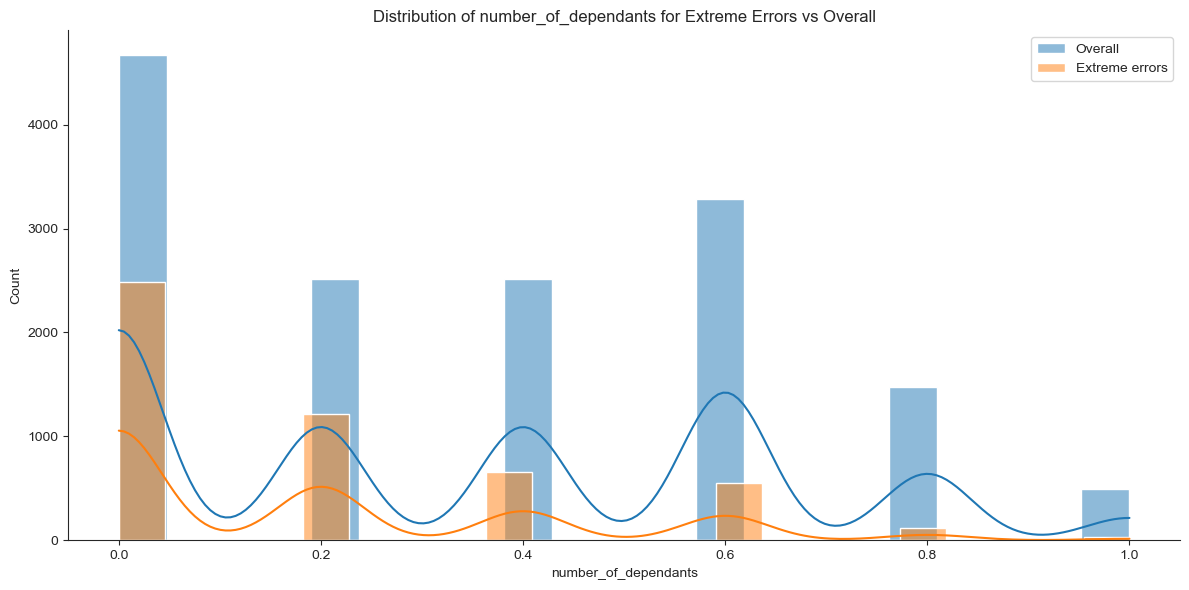

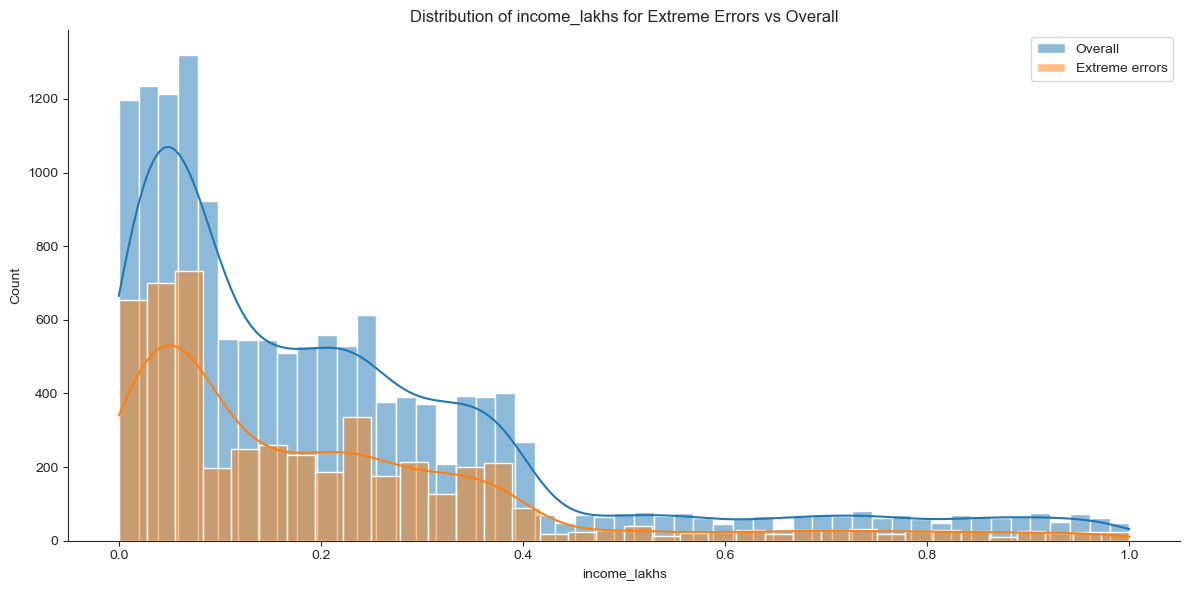

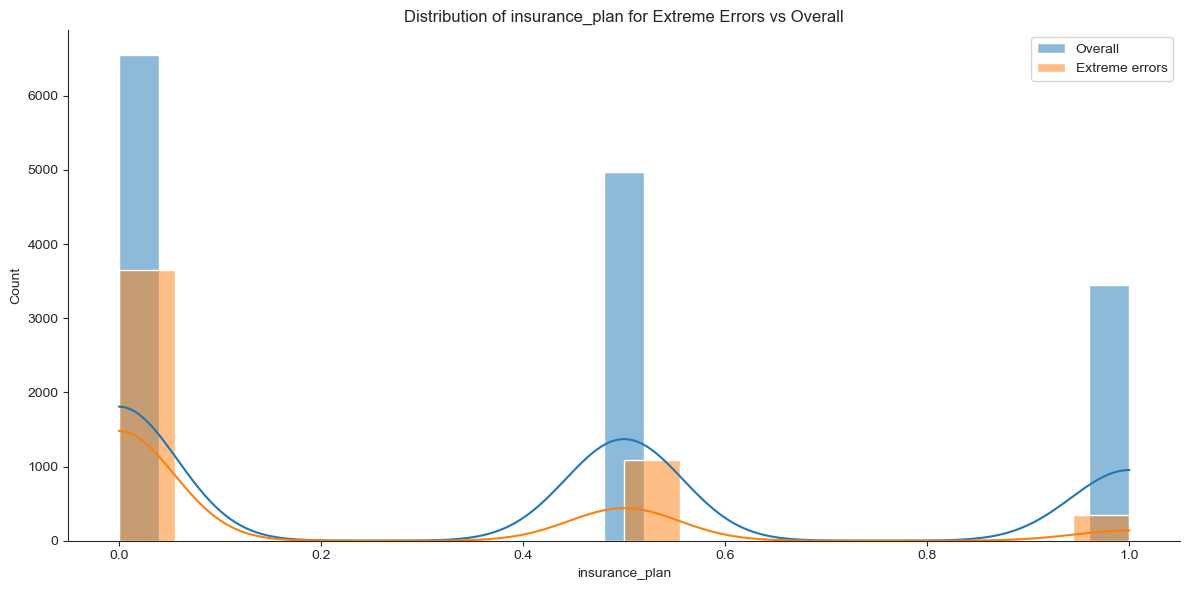

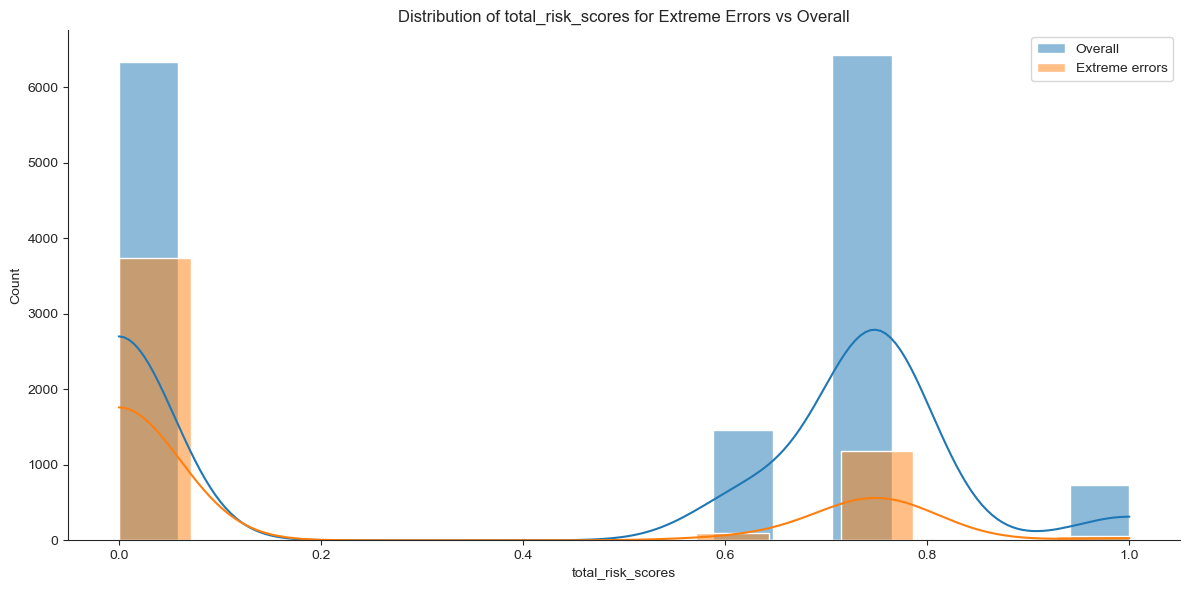

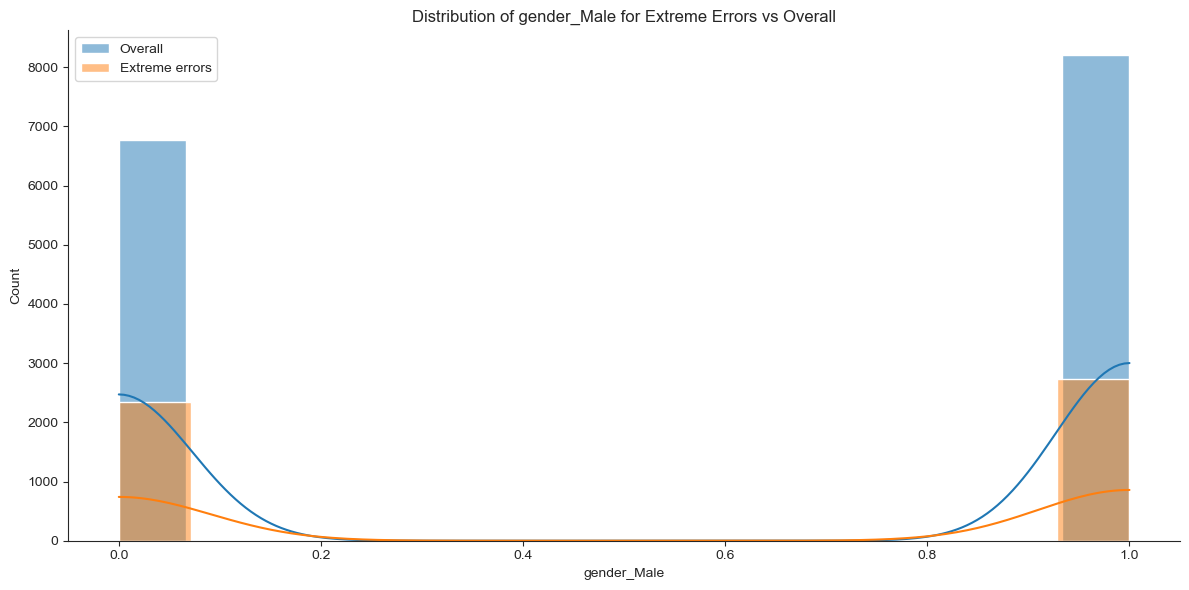

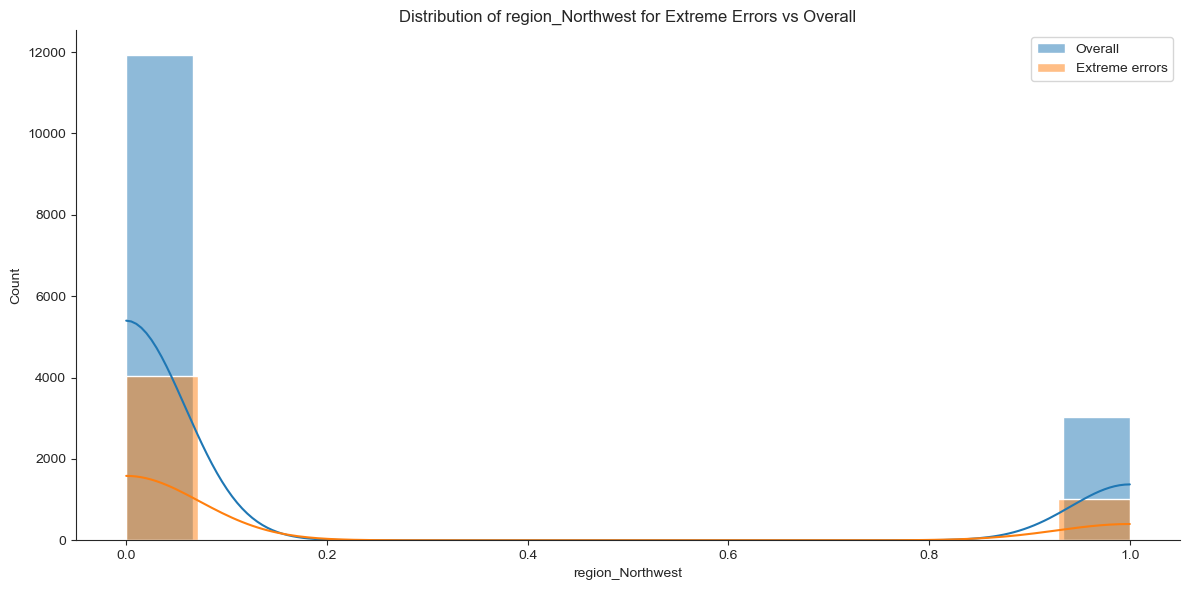

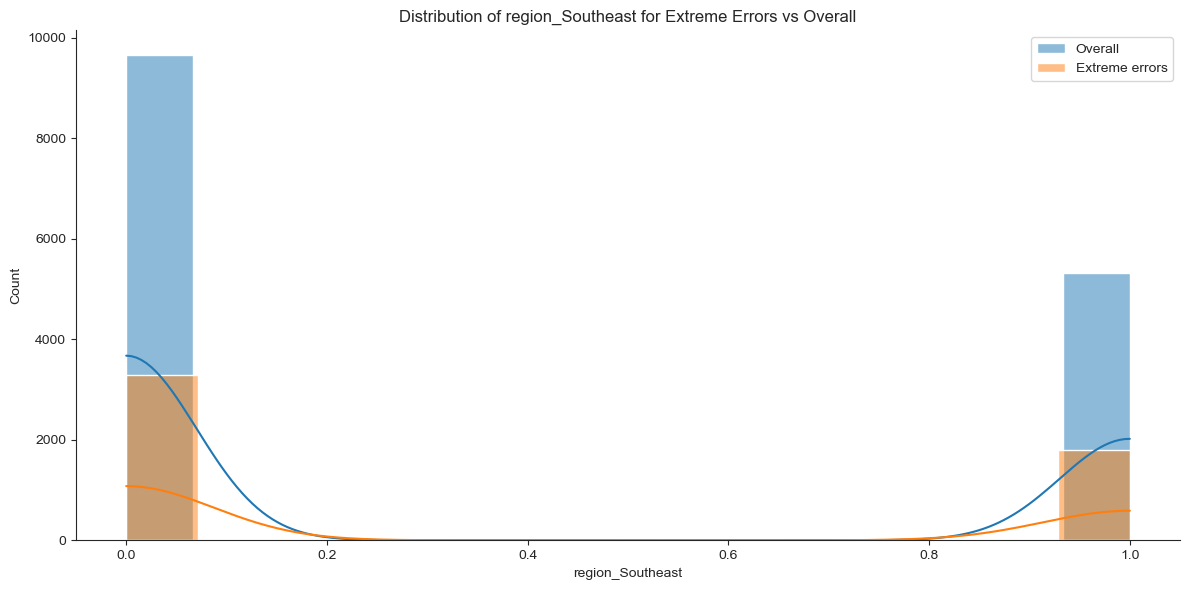

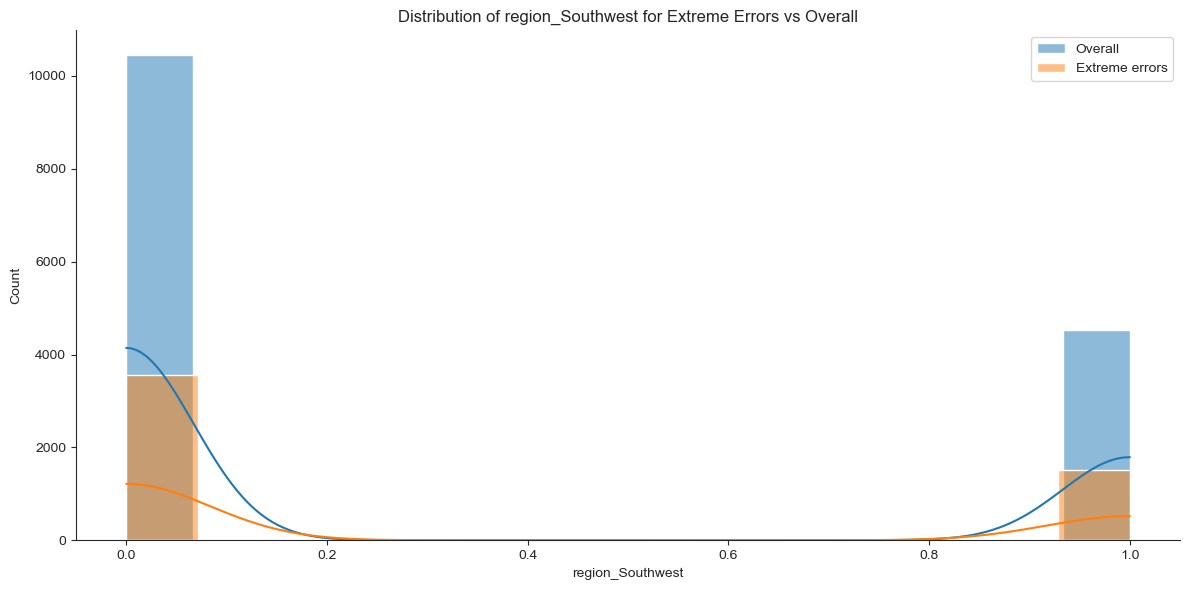

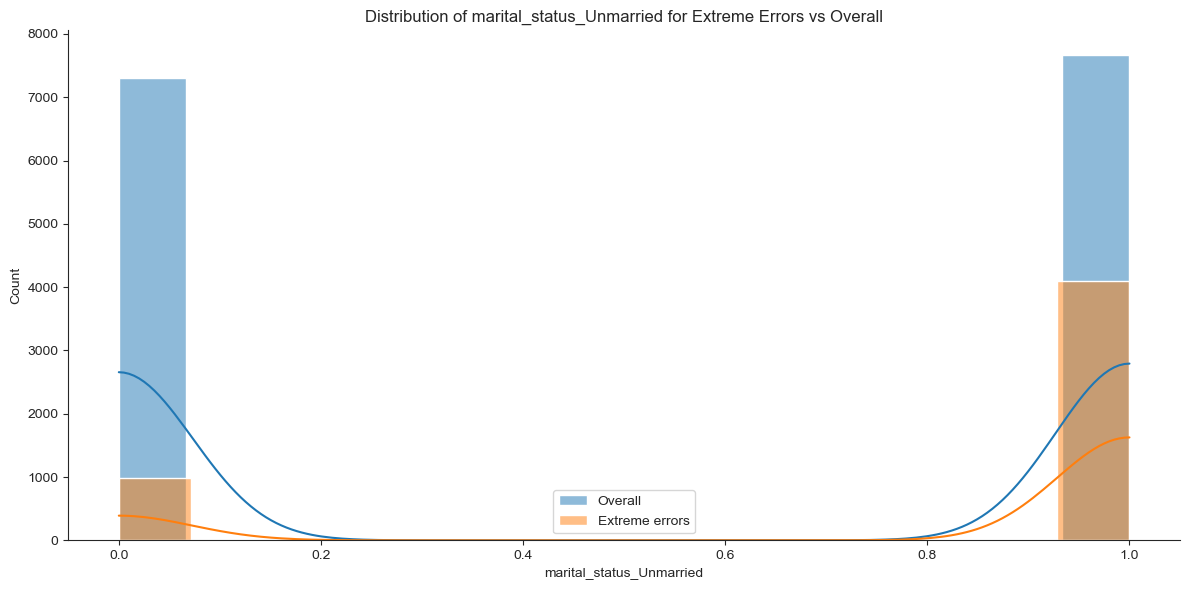

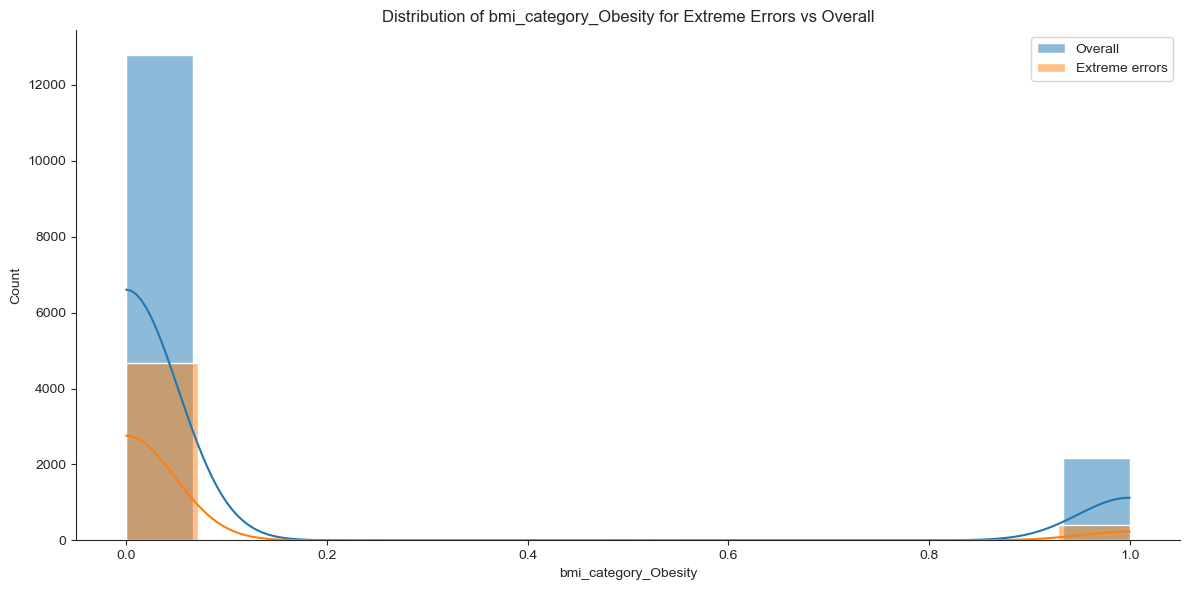

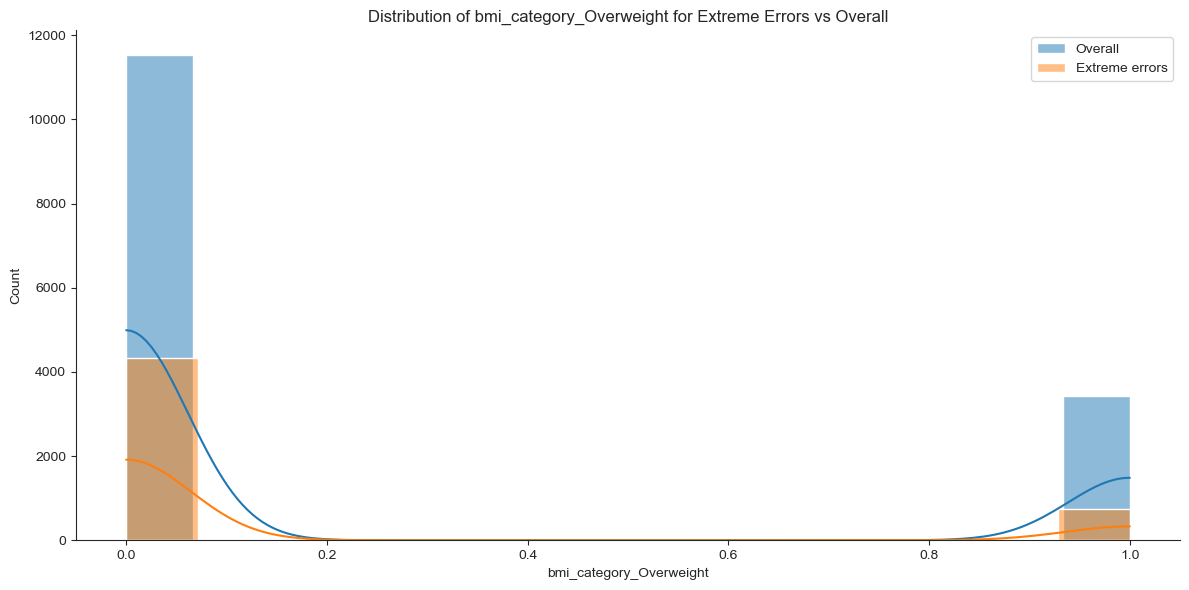

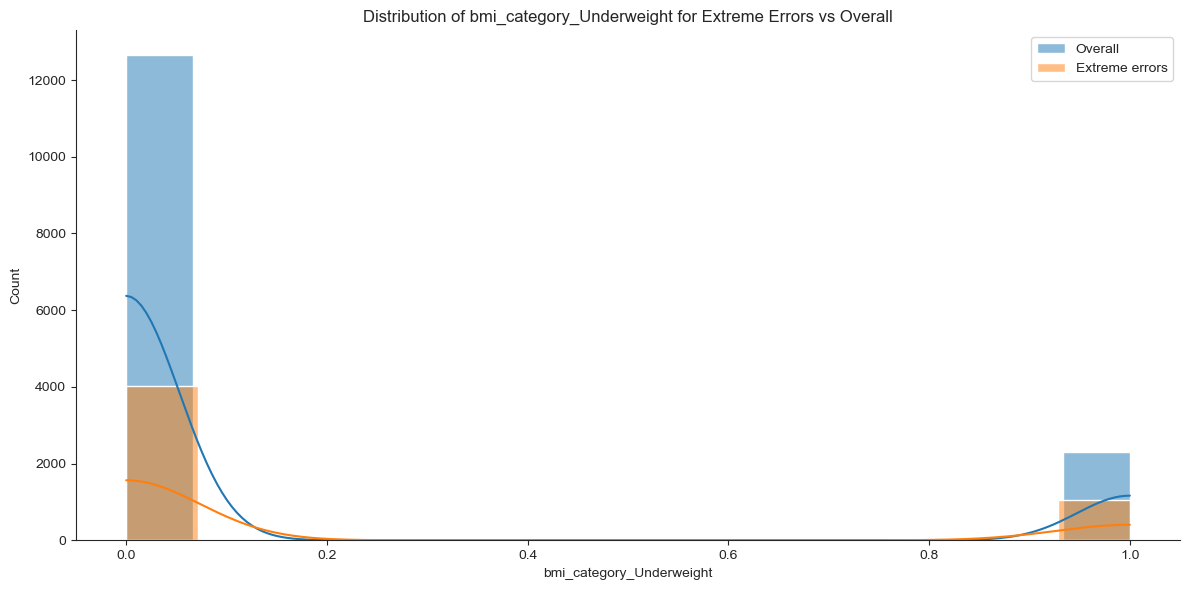

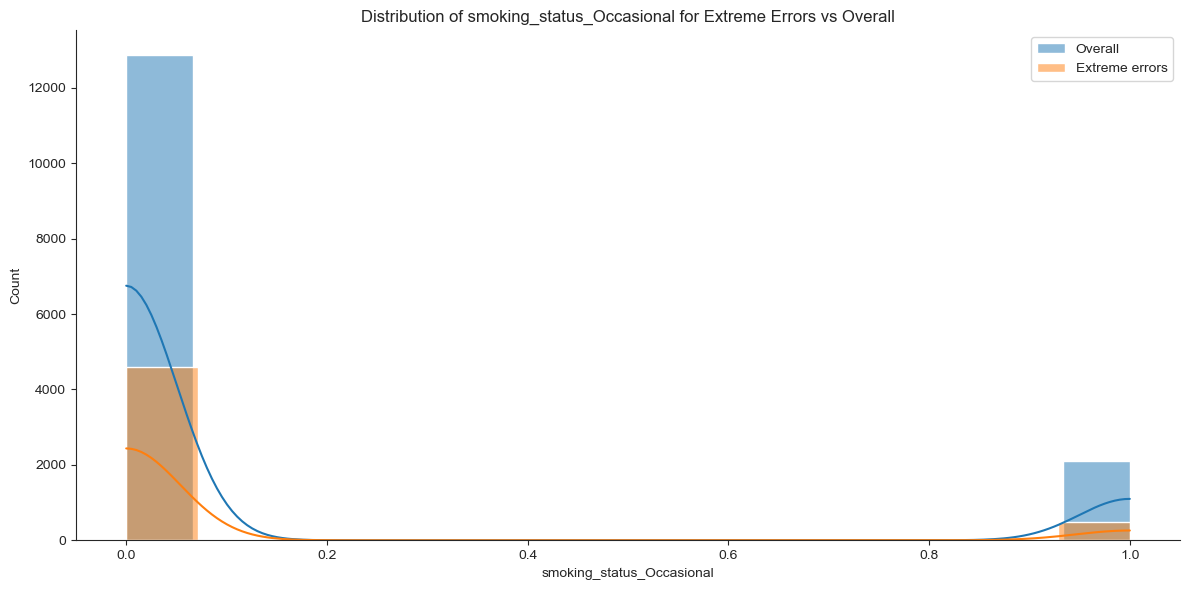

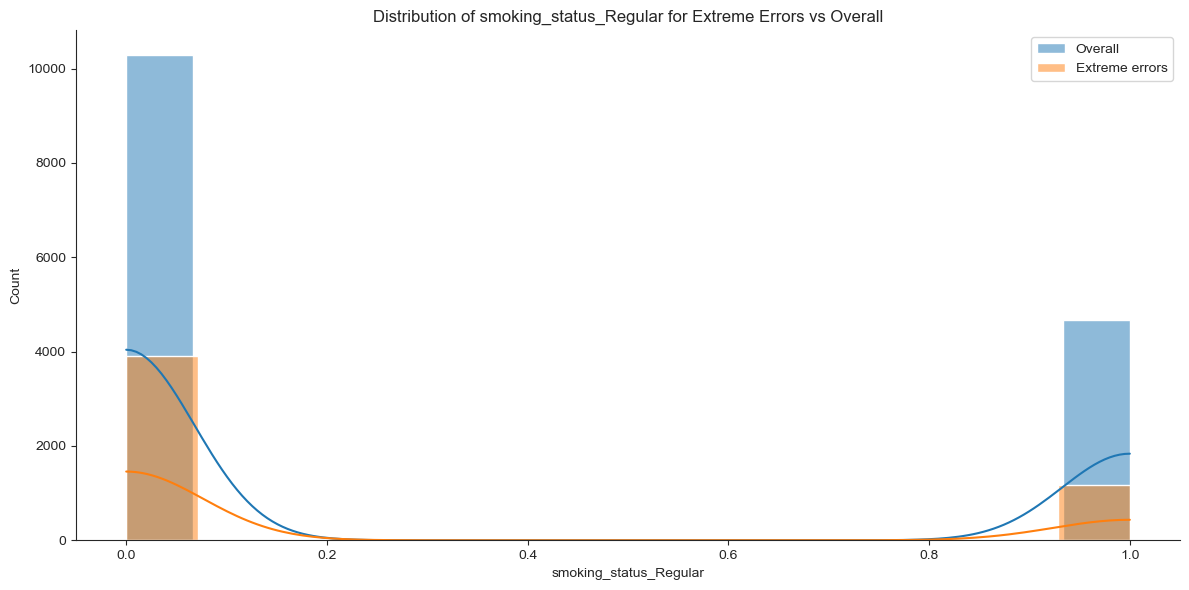

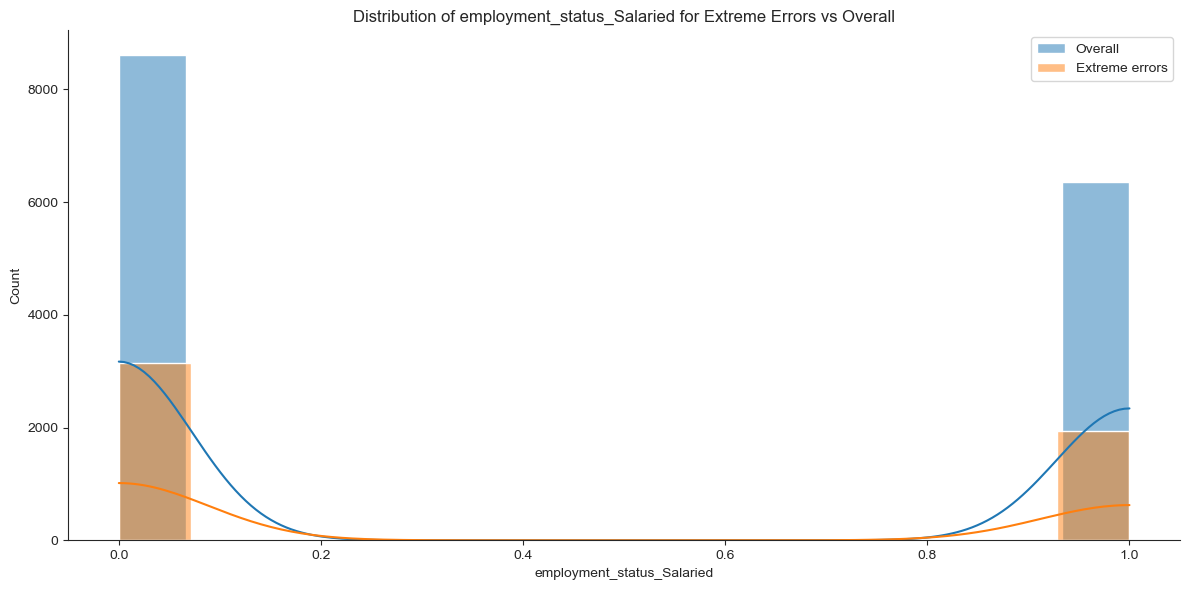

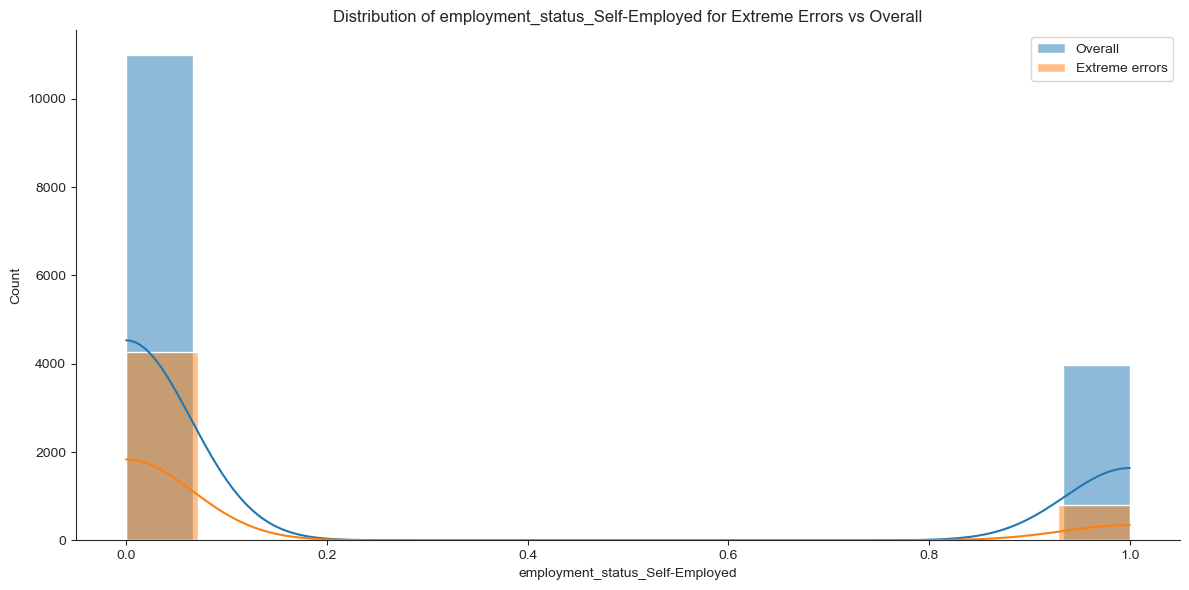

In [289]:
for feature in X_test.columns:
    plt.figure(figsize=(12,6))
    sns.set_style('ticks')
    sns.histplot(X_test[feature], kde=True, label = "Overall")
    sns.histplot(extreme_error_df[feature], kde= True, label = "Extreme errors")
    plt.title(f"Distribution of {feature} for Extreme Errors vs Overall")
    sns.despine()
    plt.tight_layout()
    plt.legend()
    plt.show()


### Reverse Scaling

In [297]:
extreme_error_df['income_level']=-1 #this column was dropped in the original so wea re just creating it as dummy

In [302]:
df_reversed = pd.DataFrame()
df_reversed[cols_to_scale] = scaler.inverse_transform(extreme_error_df[cols_to_scale])
df_reversed.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,total_risk_scores
0,23.0,1.0,-2.0,14.0,1.0,12.0
1,22.0,0.0,-2.0,21.0,1.0,12.0
2,19.0,1.0,-2.0,4.0,1.0,0.0
3,18.0,1.0,-2.0,3.0,1.0,0.0
4,21.0,0.0,-2.0,25.0,1.0,0.0


In [303]:
df_reversed.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,total_risk_scores
count,5075.000000,5075.000000,5075.0,5075.000000,5075.000000,5075.000000
mean,23.809064,0.959409,-2.0,21.017537,1.348374,3.174384
std,7.188437,1.177040,0.0,20.643383,0.601875,5.328038
min,18.000000,0.000000,-2.0,1.000000,1.000000,0.000000
25%,20.000000,0.000000,-2.0,6.000000,1.000000,0.000000
50%,22.000000,1.000000,-2.0,15.000000,1.000000,0.000000
75%,24.000000,2.000000,-2.0,30.000000,2.000000,10.000000
max,71.000000,5.000000,-2.0,100.000000,3.000000,16.000000


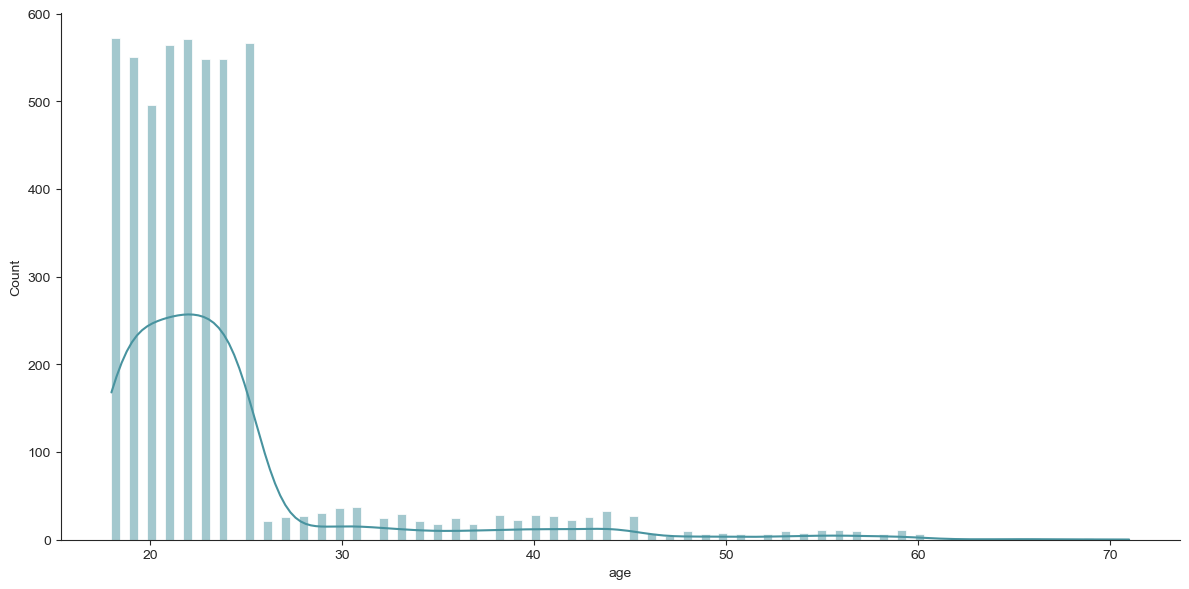

In [307]:
plt.figure(figsize=(12,6))
sns.set_style('ticks')
sns.histplot(df_reversed['age'], kde= True, color = "#48939F")
sns.despine()
plt.tight_layout()
plt.show()

This shows that majority of the extreme errors are coming from young age group (i.e. <25 years of age). We need to may be build a separate model for this segment